<div align="center">
    <h3>Aristotle University of Thessaloniki</h3>
    <h1>Analysis of Medical Images MedMNIST with CNN, Transfer Learning & Vision Transformers (Pytorch)</h1>
    <h3>Deep-Learning Winter Sem. 2025-2026</h3>
    <p>
        <b>Zisis Katsaros - 10666</b><br>
        <small>Prof.: P. Petrantonakis</small>
    </p>
</div>

## **1.** Setup  ##

### 1.1 Description of Dataset ###

In [1]:
! pip install medmnist
! python &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.5 MB/s eta 0:00:00


In [2]:
import medmnist
from medmnist import OrganSMNIST
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import random

# Define image to tensor transform 
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) 
])

# Setup training, validation, and test datasets
train_dataset = OrganSMNIST(split="train", download=True, transform=data_transform)
val_dataset = OrganSMNIST(split="val", download=True, transform=data_transform)
test_dataset = OrganSMNIST(split="test", download=True, transform=data_transform)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 64
torch.manual_seed(42) 
train_data = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_data = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_data = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Print dataset info:
print(f"==================== Dataset Info ====================")
print(f" - Name: OrganSMNIST")

num_of_classes = len(train_dataset.info['label']) # get number of classes from dataset info
print(f" - Number of classes: {num_of_classes}")

images, labels = next(iter(train_data)) # get first batch of iterator
channels, rows, cols = images.shape[1], images.shape[2], images.shape[3] # get image characteristics
if channels == 1:
    print(f" - Image size: {rows}x{cols} (Grayscale)")
elif channels == 3:
    print(f" - Image size: {rows}x{cols} (RGB)")
else:
    print(f" - Image size: {rows}x{cols}")

# get training, validation, test and total samples
train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)
num_samples = train_size + val_size + test_size

print(f" - Samples: {num_samples}")
print(f" - Training: {train_size}")
print(f" - Validation: {val_size}")
print(f" - Test: {test_size}")

100%|██████████| 16.5M/16.5M [00:01<00:00, 11.6MB/s]


==================== Dataset Info ====================
 - Name: OrganSMNIST
 - Number of classes: 11
 - Image size: 28x28 (Grayscale)
 - Samples: 25211
 - Training: 13932
 - Validation: 2452
 - Test: 8827


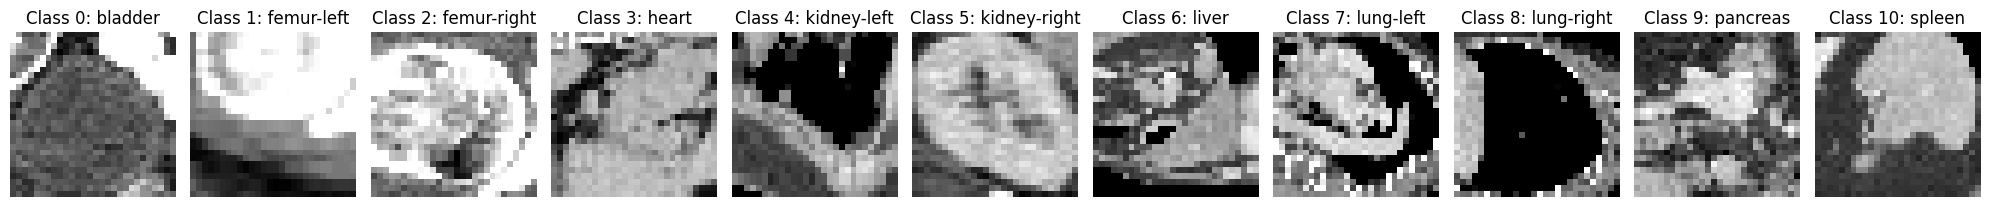

Class Distribution:
 - Class 0 (bladder): 8.24%
 - Class 1 (femur-left): 4.52%
 - Class 2 (femur-right): 4.41%
 - Class 3 (heart): 5.18%
 - Class 4 (kidney-left): 8.13%
 - Class 5 (kidney-right): 8.03%
 - Class 6 (liver): 24.86%
 - Class 7 (lung-left): 5.32%
 - Class 8 (lung-right): 5.76%
 - Class 9 (pancreas): 14.38%
 - Class 10 (spleen): 11.17%


In [3]:
# Visulaization and Class distribution

labels_dict = train_dataset.info['label'] # get lables dictionary from dataset info

fig, axes = plt.subplots(1, num_of_classes, figsize=(20, 3)) # create plot

classes = set()
num_of_samples_per_class = np.zeros(num_of_classes, dtype=int) # initialize samples per class counter 
images_dataset = OrganSMNIST(split="train", download=True, size=28) # load training dataset without transform

# iterate through the dataset
for i in range(len(images_dataset)):
    image, label = images_dataset[i]
    label = label.item()

    # plot each new class sample 
    if label not in classes:
        ax = axes[label]
        ax.imshow(image, cmap='gray')
        ax.set_title(f"Class {label}: {labels_dict[str(label)]}")
        ax.axis('off')

        classes.add(label)

    # count samples per class
    num_of_samples_per_class[label] += 1

# get distribution by dividing by total training samples
class_distribution = num_of_samples_per_class / train_size

plt.tight_layout()
plt.show()

print(f"Class Distribution:")
for i in range(num_of_classes):
    print(f" - Class {i} ({labels_dict[str(i)]}): {class_distribution[i] * 100:.2f}%")

### 1.2 Train and Test Loops ###

In [4]:
# Training Loop:
def train_loop(model, dataloader, optimizer, criterion, device):
    model.train() # model in training mode

    total_loss = 0.0
    correct = 0
    total = 0

    # iterate through training batches
    for batch, (images, labels) in enumerate(dataloader):
        images = images.to(device) 
        labels = labels.squeeze().to(device)

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # loss function
        total_loss += loss.item()

        optimizer.zero_grad() # zero the previous gradients
        loss.backward() # backpropagation
        optimizer.step() # update weights

        preds = outputs.argmax(dim=1) # get predicted class
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(dataloader), correct / total # return loss and accuracy

# Test Loop:
def test_loop(model, dataloader, criterion, device, return_probs=False):
    model.eval() # model in evaluation mode

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad(): # disable gradient calculation
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.squeeze().to(device)

            outputs = model(images) # forward pass
            loss = criterion(outputs, labels) # loss function
            total_loss += loss.item()

            preds = outputs.argmax(dim=1) # get predicted class
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy()) # store all predictions
            all_labels.extend(labels.cpu().numpy()) # store all true labels
            if return_probs:
                all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

    # return loss, accuracy, all predictions, all true labels and optional probabilities
    if return_probs:
        return total_loss / len(dataloader), correct / total, np.array(all_preds), np.array(all_labels), np.array(all_probs)
    return total_loss / len(dataloader), correct / total, np.array(all_preds), np.array(all_labels)

In [5]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

def test_config(model, train_data, val_data, test_data, criterion, learning_rate, scheduler_factor=None,scheduler_patience=None, epochs=30, num_of_classes=num_of_classes, 
                optimizer=torch.optim.Adam, early_stopping=True, patience=5, seed=42, compute_auc=True):
   
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    torch.manual_seed(seed)
    optimizer = optimizer(model.parameters(), lr=learning_rate)
    if scheduler_factor is not None and scheduler_patience is not None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')
    best_model_epoch = None
    counter = 0

    print(f"Using device: {device}")
    print(f"==================== Starting Training ====================")
    for epoch in range(epochs):
        train_loss, train_acc = train_loop(model, train_data, optimizer, criterion, device)
        val_loss, val_acc, targets, preds = test_loop(model, val_data, criterion, device)

        # Step the scheduler
        if scheduler_factor is not None and scheduler_patience is not None:
            scheduler.step(val_loss)

        # Store metrics  
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_epoch = epoch + 1
                counter = 0
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                counter += 1
                if counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    print(f"Best model at epoch {best_model_epoch}")
                    model.load_state_dict(torch.load('best_model.pth'))
                    break

        if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1}")
            print(f" - Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
            print(f" - Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

    print("==================== Training complete ====================")

    _, test_acc, test_preds, test_targets, test_probs = test_loop(model, test_data, criterion, device, return_probs=True)
    print(f">>> Test Accuracy: {test_acc*100:.2f}%")

    test_auc = None
    if compute_auc:
        if num_of_classes == 2:
            test_auc = roc_auc_score(test_targets, test_probs[:, 1])
        else:
            test_targets_bin = label_binarize(test_targets, classes=np.arange(num_of_classes))
            test_auc = roc_auc_score(test_targets_bin, test_probs, multi_class='ovr', average='macro')
        print(f">>> Test AUC: {test_auc:.4f}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'test_acc': test_acc,
        'targets': test_targets,
        'preds': test_preds,
        'test_probs': test_probs,
        'test_auc': test_auc,
        'model': model,
    }

### 1.3 Functions used for Visualization ###

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Loss, Accuracy, Confusion Matrix Plot 
def plot_loss_acc_confusion(train_losses, val_losses, train_accuracies, val_accuracies, test_acc, 
                          targets, preds, labels_dict, model_name, batch_size, learning_rate, num_of_blocks=3, batch_norm=False, layer_norm=False,
                          dropout=0.0, weight_decay=0.0, test_auc=None):
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.3)

    # Top-left: Loss curves
    ax_loss = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(train_losses) + 1)
    ax_loss.plot(epochs, train_losses, 'b-', label='Training Loss')
    ax_loss.plot(epochs, val_losses, 'r-', label='Validation Loss')
    ax_loss.set_title('Loss over Epochs')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('Loss')
    ax_loss.grid(True, alpha=0.2)
    ax_loss.legend(loc='best')

    # Top-right: Accuracy curves
    ax_acc = fig.add_subplot(gs[0, 1])
    ax_acc.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    ax_acc.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    ax_acc.set_title('Accuracy over Epochs')
    ax_acc.set_xlabel('Epochs')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_ylim(0, 1)
    ax_acc.grid(True, alpha=0.2)
    ax_acc.legend(loc='best')

    # Bottom-left: Confusion Matrix
    ax_cm = fig.add_subplot(gs[1, 0])
    confusion_mat = confusion_matrix(targets, preds)
    im = ax_cm.imshow(confusion_mat, interpolation='nearest', cmap=plt.cm.Blues)
    ax_cm.set_title('Confusion Matrix')
    fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

    class_names = [labels_dict[str(i)] for i in range(len(labels_dict))]
    tick_marks = np.arange(len(class_names))
    ax_cm.set_xticks(tick_marks)
    ax_cm.set_xticklabels(class_names, rotation=45, ha='right')
    ax_cm.set_yticks(tick_marks)
    ax_cm.set_yticklabels(class_names)

    # Annotate counts
    max_val = confusion_mat.max() if confusion_mat.size else 0
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            val = confusion_mat[i, j]
            ax_cm.text(j, i, val, ha='center', va='center',
                       color='white' if val > max_val / 2 else 'black', fontsize=9)

    # Bottom-right: Information 
    ax_text = fig.add_subplot(gs[1, 1])
    ax_text.axis('off')
    ax_text.set_title('Information', fontsize=14, fontweight='bold')

    if "MyCNN" in model_name:
        lines = [
            f" - Model: {model_name}",
            f" - Num. of Blocks: {num_of_blocks}",
            f" - Batch Size: {batch_size}",
            f" - BatchNorm: {'On' if batch_norm else 'Off'}",
            f" - LayerNorm: {'On' if layer_norm else 'Off'}",
            f" - Dropout: {'Off' if dropout == 0.0 else f'{dropout*100:.0f}%'}",
            f" - Weight Decay: {weight_decay}",
            f" - Learning Rate: {learning_rate}",
            f" >>> Test Accuracy: {test_acc*100:.2f}%",
            f" >>> Test AUC: {test_auc:.4f}" if test_auc is not None else ""
        ]

    else:
        lines = [
            f" - Model: {model_name}",
            f" - Batch Size: {batch_size}",
            f" - Learning Rate: {learning_rate}",
            f" >>> Test Accuracy: {test_acc*100:.2f}%",
            f" >>> Test AUC: {test_auc:.4f}" if test_auc is not None else ""
        ]

    y0 = 0.9
    dy = 0.10
    for i, line in enumerate(lines):
        ax_text.text(0.0, y0 - i * dy, line, transform=ax_text.transAxes, fontsize=10, va='top')

    plt.tight_layout()
    plt.show()


# Loss and Accuracy Plot
def plot_loss_acc_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.2)
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Confusion Matrix Plot
def plot_confusion_matrix(targets, preds, labels):
    confusion_mat = confusion_matrix(targets, preds)
    class_names = [labels[str(i)] for i in range(len(labels))]

    plt.figure(figsize=(8, 6))
    plt.imshow(confusion_mat, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = range(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

     # Annotate counts
    max_val = confusion_mat.max() if confusion_mat.size else 0
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            val = confusion_mat[i, j]
            plt.text(j, i, val, ha='center', va='center',
                       color='white' if val > max_val / 2 else 'black', fontsize=9)
            
    plt.show()


### 1.4 Weighted Loss ###

In [7]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')


class_weights = train_size / (num_of_classes * num_of_samples_per_class) # no class has 0 samples so no need to add epsilon 
class_weights = np.sqrt(class_weights)  # apply square root to sofen weights
weights_tensor = torch.FloatTensor(class_weights).to(device) 
print(class_weights)

Using device: cpu
[1.05036308 1.41788209 1.43623731 1.32538716 1.05776009 1.06388662
 0.60467421 1.30737834 1.25589294 0.79498975 0.90220576]


## **2.** CNN from scratch ##

### 2.1 MyCNN ###

In [11]:
import numpy as np
import torch
from torch import nn

class MyCNN(nn.Module):
    def __init__(self, img_size, num_of_channels, num_of_classes, num_of_filters=32, num_of_blocks=3, batch_norm=False, 
                 layer_norm=False, dropout_prob=0.0):
        super(MyCNN, self).__init__()

        self.blocks = nn.ModuleList() # list to hold convolutional blocks

        in_channels = num_of_channels # initial input channel size = number of image channels
        out_channels = num_of_filters # initial output channel size = number of filters

        # Convolutional Blocks: Conv2d -> (BatchNorm) -> ReLU -> MaxPool2d -> (LayerNorm)
        for i in range(num_of_blocks):
            self.blocks.append(nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels) if batch_norm else nn.Identity(),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2),
                nn.LayerNorm([out_channels, img_size // (2 ** (i + 1)), img_size // (2 ** (i + 1))]) if layer_norm else nn.Identity()
            ))
            in_channels = out_channels # update input channels for next block
            out_channels *= 2  # double output channels for next block 

            # Calculate final image size 
            final_img_size = img_size // (2 ** num_of_blocks) # halfed for each block due to MaxPool2d

            if final_img_size < 1:
                print(f"Image size too small for the number of blocks.") 

            self.flatten_dim = in_channels * final_img_size ** 2     

            # Fully Connected Layer:
            self.dropout = nn.Dropout(dropout_prob) if dropout_prob > 0 else nn.Identity()
            self.fc1 = nn.Linear(self.flatten_dim, num_of_classes)     

    def forward(self, x):
        for block in self.blocks:
            x = block(x) # pass through each convolutional block

        x = x.flatten(1)

        x = self.dropout(x) 
        x = self.fc1(x)
        return x

### 2.2 Training with different Hyperparameter Values ###

#### I. Default: 3 Blocks, Batch size: 64, learning rate: 1e-3, 30 Epochs ####

In [24]:
img_size = rows # square images

MyCNN_default = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes)
MyCNN_default.to(device)
# print(MyCNN_default)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam

early_stopping = True
patience = 5

results_default = test_config(
    model=MyCNN_default,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    optimizer=optimizer,
    early_stopping=True,
    patience=patience,
    compute_auc=True
    )

train_losses_default = results_default['train_losses']
val_losses_default = results_default['val_losses']
train_accuracies_default = results_default['train_accuracies']
val_accuracies_default = results_default['val_accuracies']
test_acc_default = results_default['test_acc']
test_auc_default = results_default['test_auc']
targets = results_default['targets']
preds = results_default['preds']

Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 1.1305, Train Acc: 60.18%
 - Val Loss: 0.5390, Val Acc: 80.46%

Epoch 5
 - Train Loss: 0.3086, Train Acc: 88.47%
 - Val Loss: 0.4196, Val Acc: 86.75%

Early stopping at epoch 8
Best model at epoch 3
==================== Training complete ====================
>>> Test Accuracy: 74.74%
>>> Test AUC: 0.9679


/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


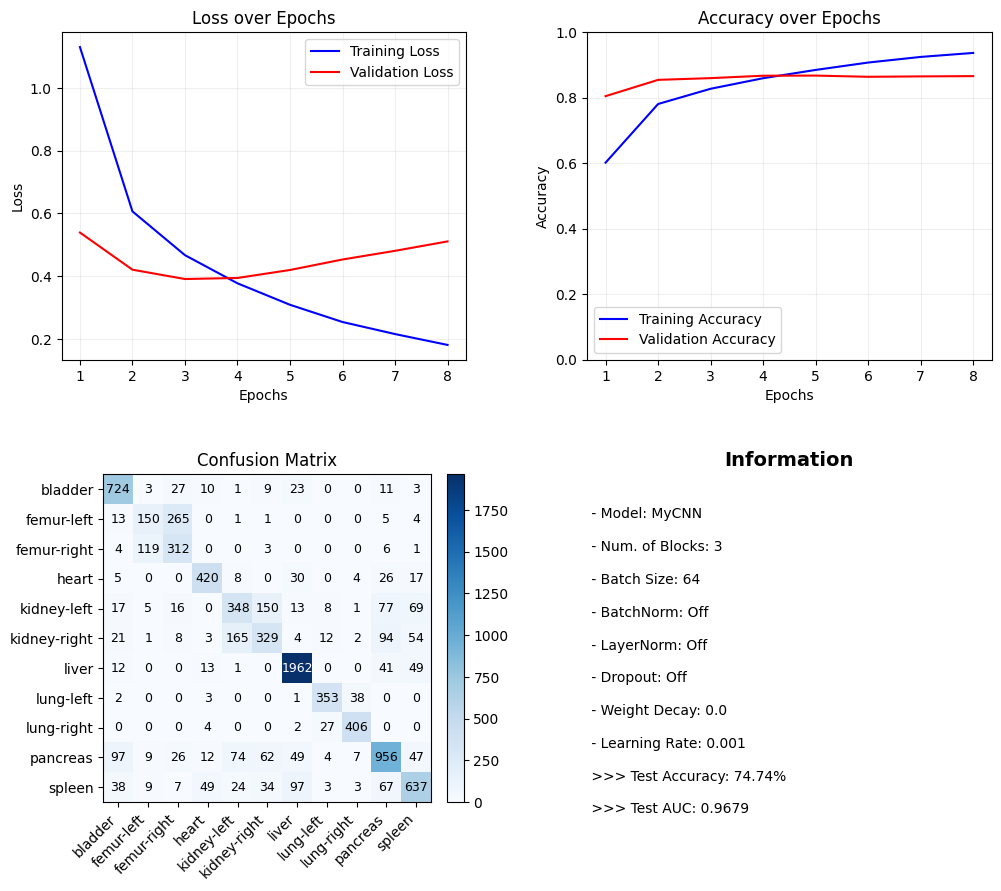

In [29]:
# Visualization
plot_loss_acc_confusion(train_losses_default, val_losses_default, train_accuracies_default, val_accuracies_default, test_acc_default,
                          targets, preds, labels_dict,model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, test_auc=test_auc_default)

#### II. 4 Blocks ####

In [31]:

img_size = rows # square images

MyCNN_4Blocks = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4) 
MyCNN_4Blocks.to(device)
# print(MyCNN_4Blocks)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

early_stopping = True
patience = 5

results_4Blocks = test_config(
    model=MyCNN_4Blocks,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    optimizer=optimizer,
    early_stopping=True,
    patience=patience,
    compute_auc=True
    )

train_losses_4Blocks = results_4Blocks['train_losses']
val_losses_4Blocks = results_4Blocks['val_losses']
train_accuracies_4Blocks = results_4Blocks['train_accuracies']
val_accuracies_4Blocks = results_4Blocks['val_accuracies']
test_acc_4Blocks = results_4Blocks['test_acc']
test_auc_4Blocks = results_4Blocks['test_auc']
targets = results_4Blocks['targets']
preds = results_4Blocks['preds']
 

Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 1.0909, Train Acc: 59.39%
 - Val Loss: 0.5130, Val Acc: 82.06%

Epoch 5
 - Train Loss: 0.2287, Train Acc: 90.38%
 - Val Loss: 0.4308, Val Acc: 85.85%

Early stopping at epoch 8
Best model at epoch 3
==================== Training complete ====================
>>> Test Accuracy: 75.45%
>>> Test AUC: 0.9709


/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


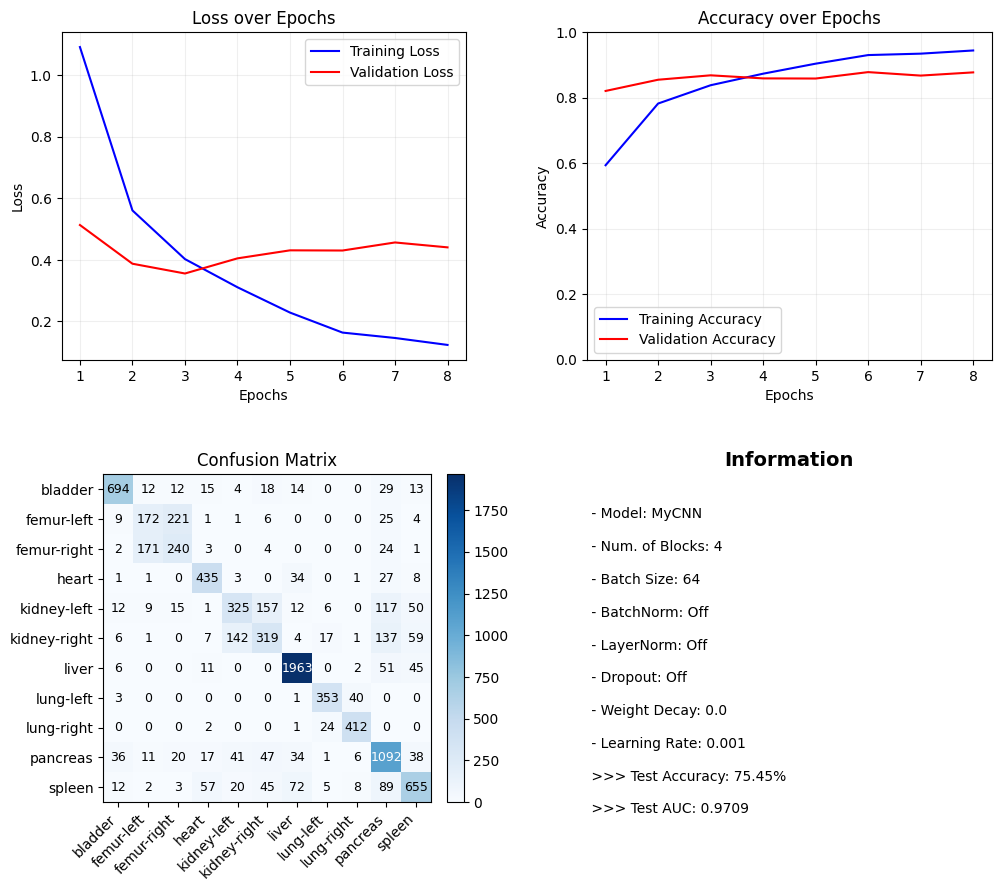

In [32]:
# Visualization
plot_loss_acc_confusion(train_losses_4Blocks, val_losses_4Blocks, train_accuracies_4Blocks, val_accuracies_4Blocks, test_acc_4Blocks,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=4, test_auc=test_auc_4Blocks)

#### III. Batch Normalization: 3 Blocks, learning rate: 5e-4, batch_norm on ####

In [34]:
img_size = rows # square images

MyCNN_BatchNorm = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, batch_norm=True) 
MyCNN_BatchNorm.to(device)
# print(MyCNN_BatchNorm)

epochs = 30
learning_rate = 5e-4
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

early_stopping = True
patience = 5

results_BatchNorm = test_config(
    model=MyCNN_BatchNorm,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    optimizer=optimizer,
    early_stopping=True,
    patience=patience,
    compute_auc=True
    )

train_losses_BatchNorm = results_BatchNorm['train_losses']
val_losses_BatchNorm = results_BatchNorm['val_losses']
train_accuracies_BatchNorm = results_BatchNorm['train_accuracies']
val_accuracies_BatchNorm = results_BatchNorm['val_accuracies']
test_acc_BatchNorm = results_BatchNorm['test_acc']
test_auc_BatchNorm = results_BatchNorm['test_auc']
targets = results_BatchNorm['targets']
preds = results_BatchNorm['preds']



Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.8364, Train Acc: 70.57%
 - Val Loss: 0.4012, Val Acc: 84.79%

Epoch 5
 - Train Loss: 0.1917, Train Acc: 93.64%
 - Val Loss: 0.3105, Val Acc: 88.01%

Epoch 10
 - Train Loss: 0.0725, Train Acc: 98.21%
 - Val Loss: 0.3783, Val Acc: 86.46%

Early stopping at epoch 13
Best model at epoch 8
==================== Training complete ====================
>>> Test Accuracy: 75.70%
>>> Test AUC: 0.9721


/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


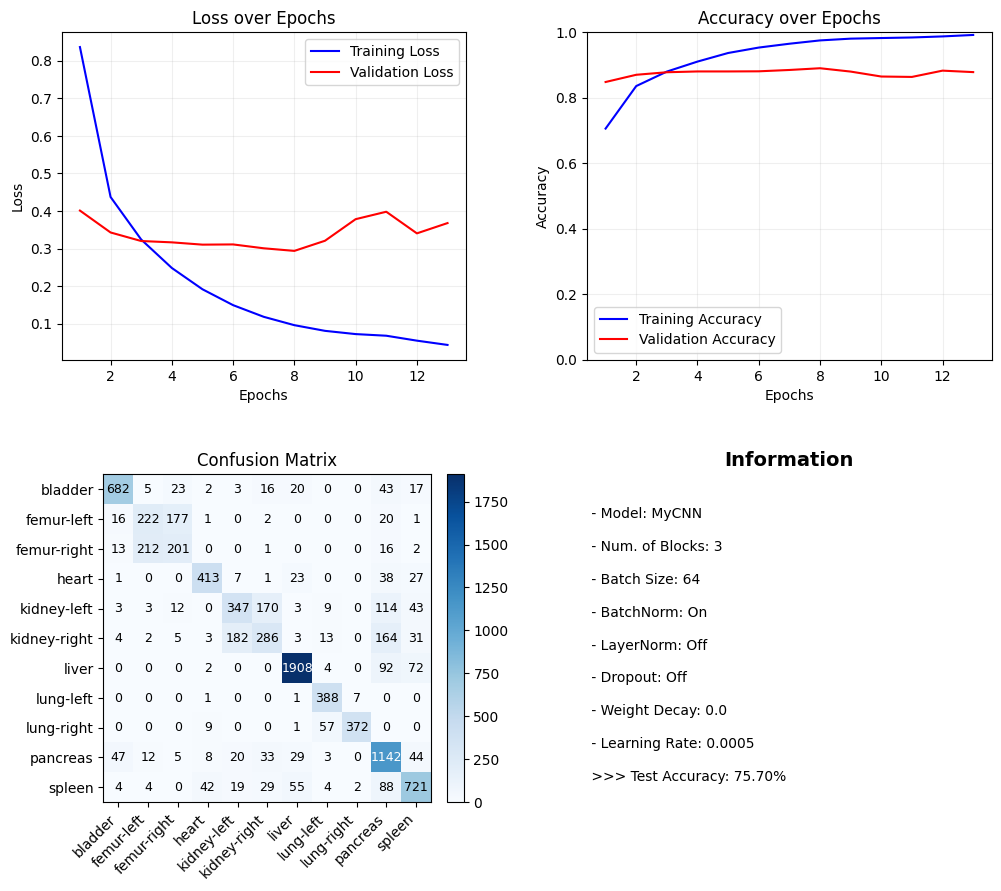

In [35]:
# Visualization
plot_loss_acc_confusion(train_losses_BatchNorm, val_losses_BatchNorm, train_accuracies_BatchNorm, val_accuracies_BatchNorm, test_acc_BatchNorm,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, batch_norm=True)

#### IV. Layer Normalization: 4 Blocks, learning rate: 5e-4, layer_norm on ####

In [38]:
img_size = rows # square images

MyCNN_LayerNorm = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4, layer_norm=True) 
MyCNN_LayerNorm.to(device)
# print(MyCNN_LayerNorm)

epochs = 30
learning_rate = 5e-4
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam

early_stopping = True
patience = 5

results_LayerNorm = test_config(
    model=MyCNN_LayerNorm,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    early_stopping=early_stopping,
    patience=patience,
    compute_auc=True,
    seed=42,
 )

train_losses_LayerNorm = results_LayerNorm['train_losses']
val_losses_LayerNorm = results_LayerNorm['val_losses']
train_accuracies_LayerNorm = results_LayerNorm['train_accuracies']
val_accuracies_LayerNorm = results_LayerNorm['val_accuracies']
test_acc_LayerNorm = results_LayerNorm['test_acc']
test_auc_LayerNorm = results_LayerNorm['test_auc']
targets = results_LayerNorm['targets']
preds = results_LayerNorm['preds']

Using device: cuda
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.7017, Train Acc: 74.74%
 - Val Loss: 0.3614, Val Acc: 86.05%

Epoch 5
 - Train Loss: 0.0714, Train Acc: 97.21%
 - Val Loss: 0.3120, Val Acc: 88.54%

Early stopping at epoch 9
Best model at epoch 4
==================== Training complete ====================
>>> Test Accuracy: 76.16%
>>> Test AUC: 0.9717


/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


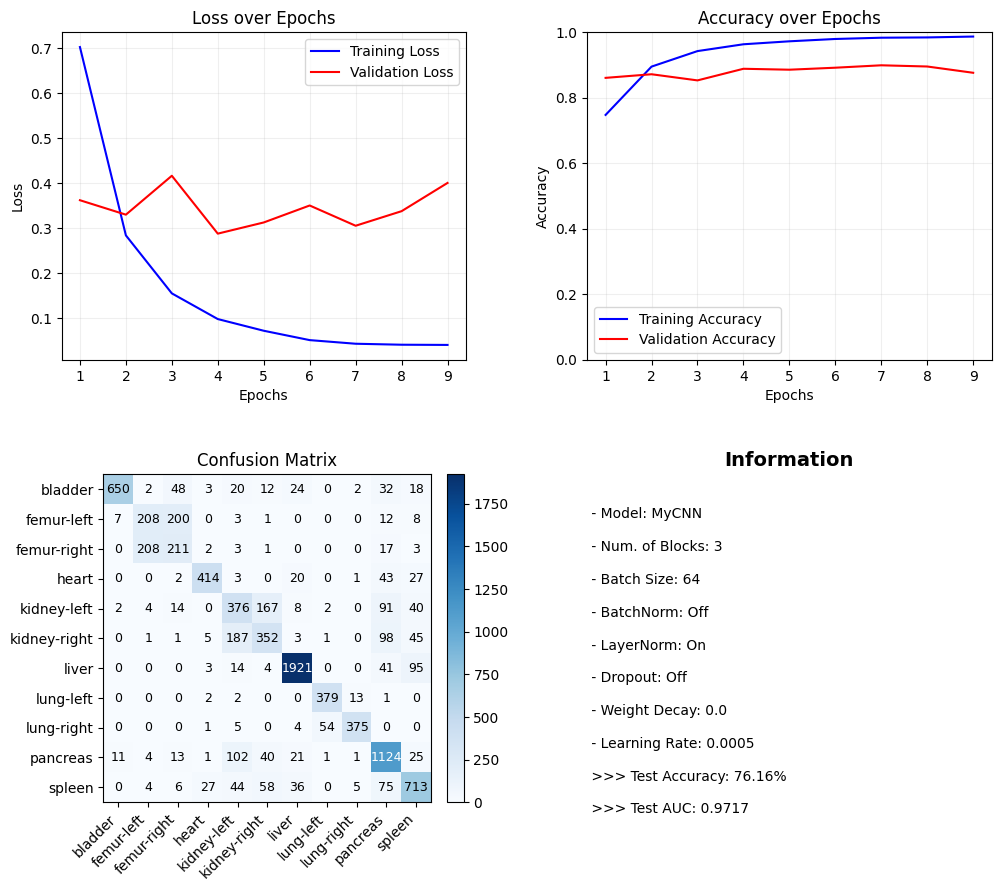

In [39]:
# Visualization
plot_loss_acc_confusion(train_losses_LayerNorm, val_losses_LayerNorm, train_accuracies_LayerNorm, val_accuracies_LayerNorm, test_acc_LayerNorm,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, layer_norm=True, 
                          test_auc=test_auc_LayerNorm)

#### V. Dropout: 4 Blocks, learning rate: 1e-3, dropout_prob: 20%, 50%, 70% ####

In [41]:
img_size = rows # square images

dropout_array = [0.2, 0.5, 0.7]
train_losses_array_Drop = []
val_losses_array_Drop = []
train_accuracies_array_Drop = []
val_accuracies_array_Drop = []
test_accuracies_array_Drop = []

for idx in range(len(dropout_array)):
    dropout_prob = dropout_array[idx]
    print(f"\n******************** Training with Dropout Probability: {dropout_prob*100:.0f}% ********************")
    MyCNN_Drop = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4, dropout_prob=dropout_prob) 
    MyCNN_Drop.to(device)
    # print(MyCNN_Drop)

    epochs = 30
    learning_rate = 1e-3
    batch_size = BATCH_SIZE
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam
    
    early_stopping = True
    patience = 5

    results_Drop = test_config(
        model=MyCNN_Drop,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        criterion=criterion,
        learning_rate=learning_rate,
        epochs=epochs,
        num_of_classes=num_of_classes,
        optimizer=optimizer,
        early_stopping=early_stopping,
        patience=patience,
        compute_auc=True,
        seed=42
    )  

    train_losses_Drop = results_Drop['train_losses']
    val_losses_Drop = results_Drop['val_losses']
    train_accuracies_Drop = results_Drop['train_accuracies']
    val_accuracies_Drop = results_Drop['val_accuracies']
    test_acc_Drop = results_Drop['test_acc']
    targets = results_Drop['targets']
    preds = results_Drop['preds']

    train_losses_array_Drop.append(train_losses_Drop)
    val_losses_array_Drop.append(val_losses_Drop)
    train_accuracies_array_Drop.append(train_accuracies_Drop)
    val_accuracies_array_Drop.append(val_accuracies_Drop)
    test_accuracies_array_Drop.append(test_acc_Drop)


******************** Training with Dropout Probability: 20% ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 1.0878, Train Acc: 58.93%
 - Val Loss: 0.4824, Val Acc: 83.36%

Epoch 5
 - Train Loss: 0.2633, Train Acc: 88.77%
 - Val Loss: 0.4200, Val Acc: 85.64%

Early stopping at epoch 9
Best model at epoch 4
==================== Training complete ====================
>>> Test Accuracy: 75.94%
>>> Test AUC: 0.9710

******************** Training with Dropout Probability: 50% ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 1.2007, Train Acc: 55.08%
 - Val Loss: 0.5193, Val Acc: 81.28%

Epoch 5
 - Train Loss: 0.3462, Train Acc: 84.96%
 - Val Loss: 0.3290, Val Acc: 87.52%

Epoch 10
 - Train Loss: 0.1843, Train Acc: 91.80%
 - Val Loss: 0.3166, Val Acc: 88.09%

Early stopping at epoch 15
Best model at epoch 10
==================== Training complet

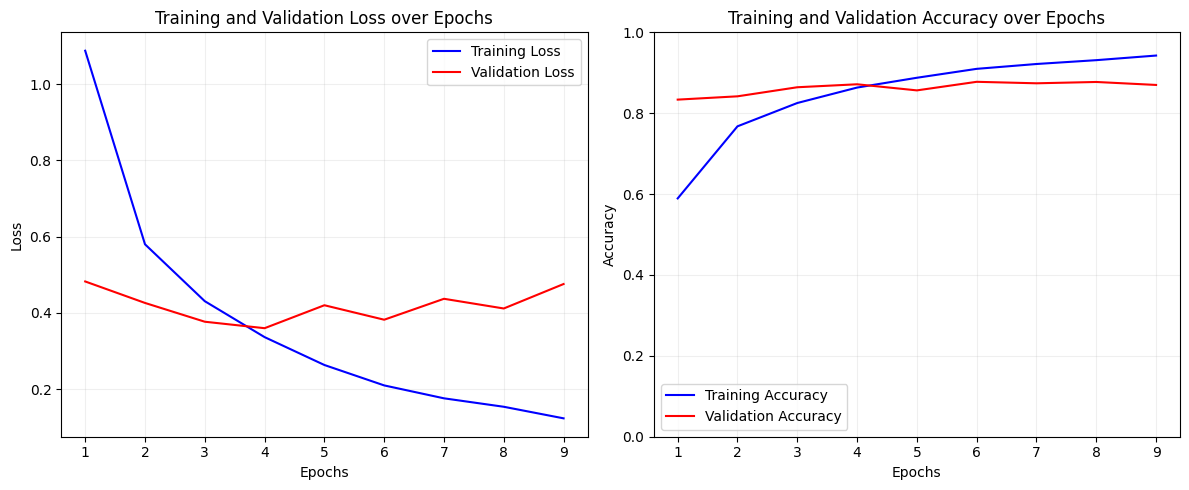

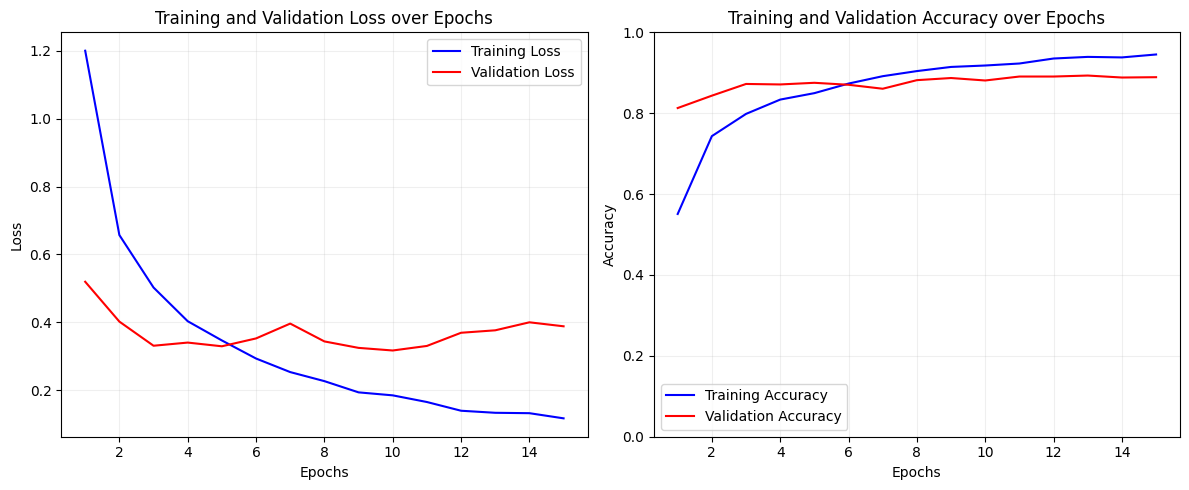

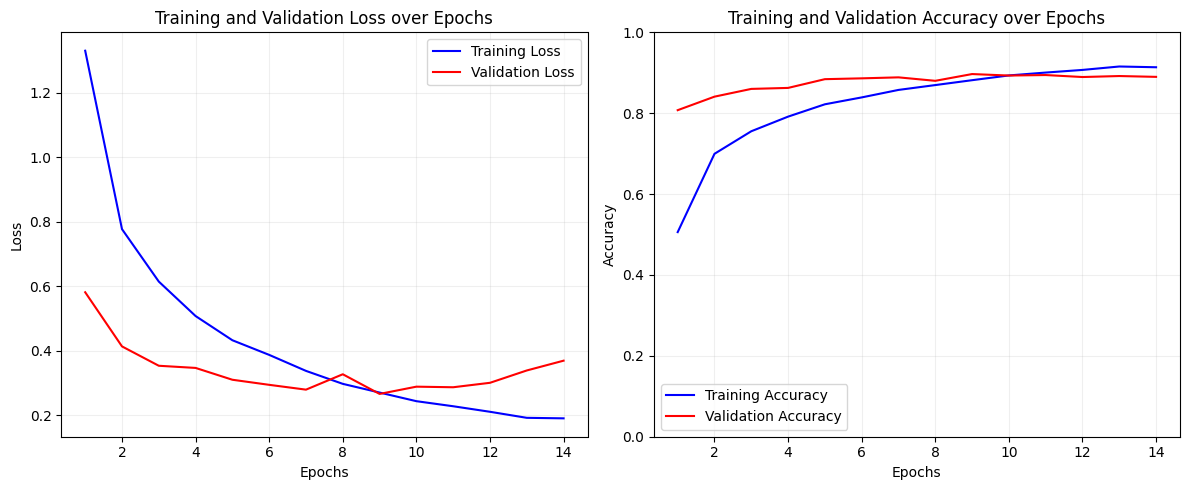

In [43]:
# Visualization
for idx in range(len(dropout_array)):
    dropout_prob = dropout_array[idx]
    plot_loss_acc_curves(train_losses_array_Drop[idx], val_losses_array_Drop[idx], train_accuracies_array_Drop[idx], val_accuracies_array_Drop[idx])

#### VI. Weight Decay: 4 Blocks, learning rate: 1e-3, weight_decay: 1e-4, 1e-3, 1e-2 ####

In [44]:
img_size = rows  # square images

weight_decay_array = [1e-4, 1e-3, 1e-2]
train_losses_array_WD = []
val_losses_array_WD = []
train_accuracies_array_WD = []
val_accuracies_array_WD = []
test_accuracies_array_WD = []

for idx in range(len(weight_decay_array)):
    weight_decay = weight_decay_array[idx]
    print(f"\n******************** Training with Weight Decay: {weight_decay} ********************")
    MyCNN_WD = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4)
    MyCNN_WD.to(device)

    epochs = 30
    learning_rate = 1e-3
    batch_size = BATCH_SIZE
    criterion = torch.nn.CrossEntropyLoss()

    # create optimizer factory that includes weight_decay
    optimizer_fn = lambda params, lr: torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

    results_wd = test_config(
        model=MyCNN_WD,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        criterion=criterion,
        learning_rate=learning_rate,
        epochs=epochs,
        num_of_classes=num_of_classes,
        optimizer=optimizer_fn,
        early_stopping=True,
        patience=5,
        compute_auc=True,
        seed=42,
    )

    train_losses_WD = results_wd['train_losses']
    val_losses_WD = results_wd['val_losses']
    train_accuracies_WD = results_wd['train_accuracies']
    val_accuracies_WD = results_wd['val_accuracies']
    test_acc_WD = results_wd['test_acc']
    batch_size = batch_size
    learning_rate = learning_rate

    train_losses_array_WD.append(train_losses_WD)
    val_losses_array_WD.append(val_losses_WD)
    train_accuracies_array_WD.append(train_accuracies_WD)
    val_accuracies_array_WD.append(val_accuracies_WD)
    test_accuracies_array_WD.append(test_acc_WD)


******************** Training with Weight Decay: 0.0001 ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 1.0900, Train Acc: 59.17%
 - Val Loss: 0.4835, Val Acc: 82.59%

Epoch 5
 - Train Loss: 0.2318, Train Acc: 90.10%
 - Val Loss: 0.4668, Val Acc: 86.99%

Early stopping at epoch 8
Best model at epoch 3
==================== Training complete ====================
>>> Test Accuracy: 74.70%
>>> Test AUC: 0.9689

******************** Training with Weight Decay: 0.001 ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 1.1322, Train Acc: 58.12%
 - Val Loss: 0.5173, Val Acc: 81.40%

Epoch 5
 - Train Loss: 0.2801, Train Acc: 88.55%
 - Val Loss: 0.3970, Val Acc: 87.15%

Early stopping at epoch 8
Best model at epoch 3
==================== Training complete ====================
>>> Test Accuracy: 74.76%
>>> Test AUC: 0.9703

******************** Trainin

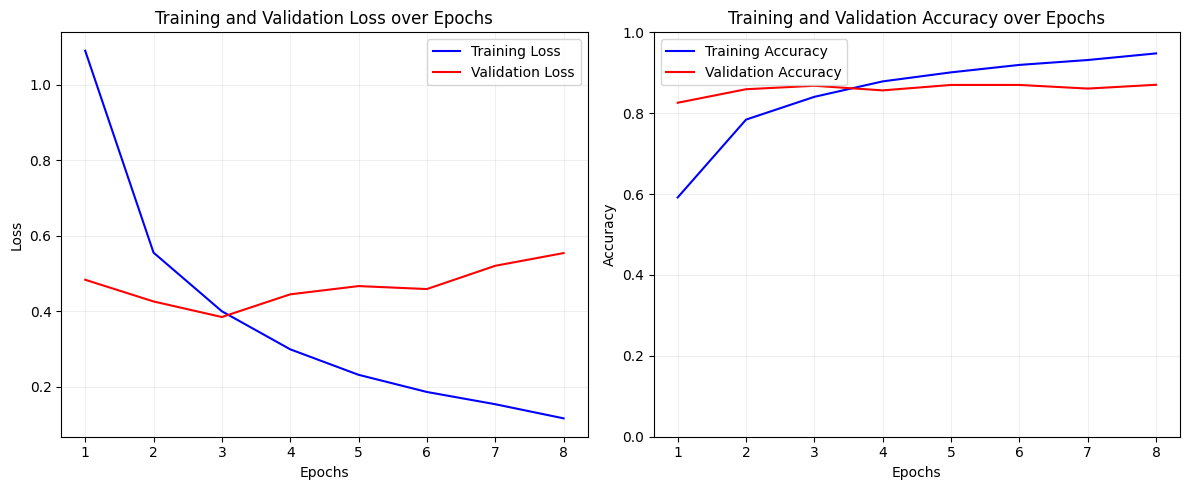

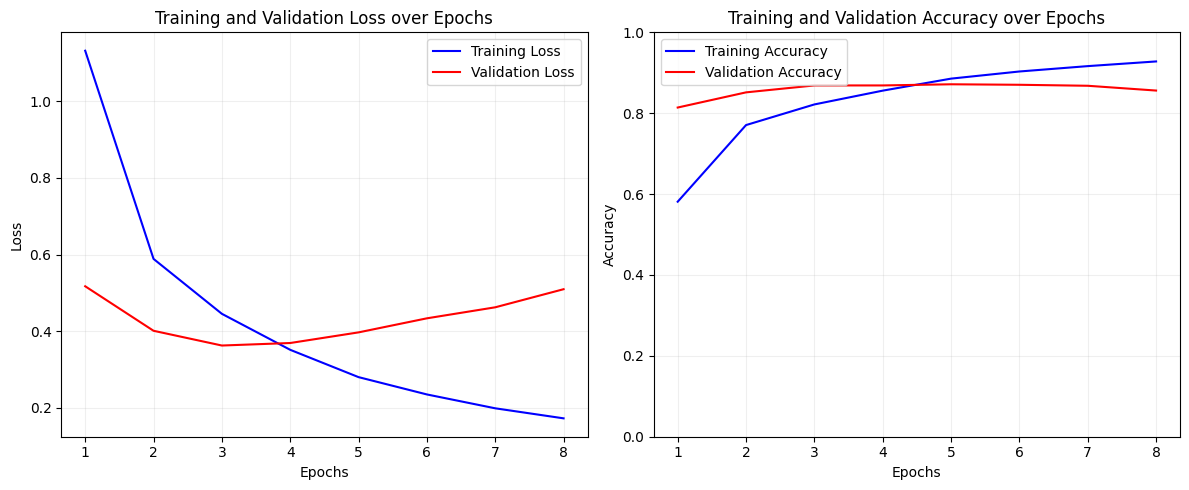

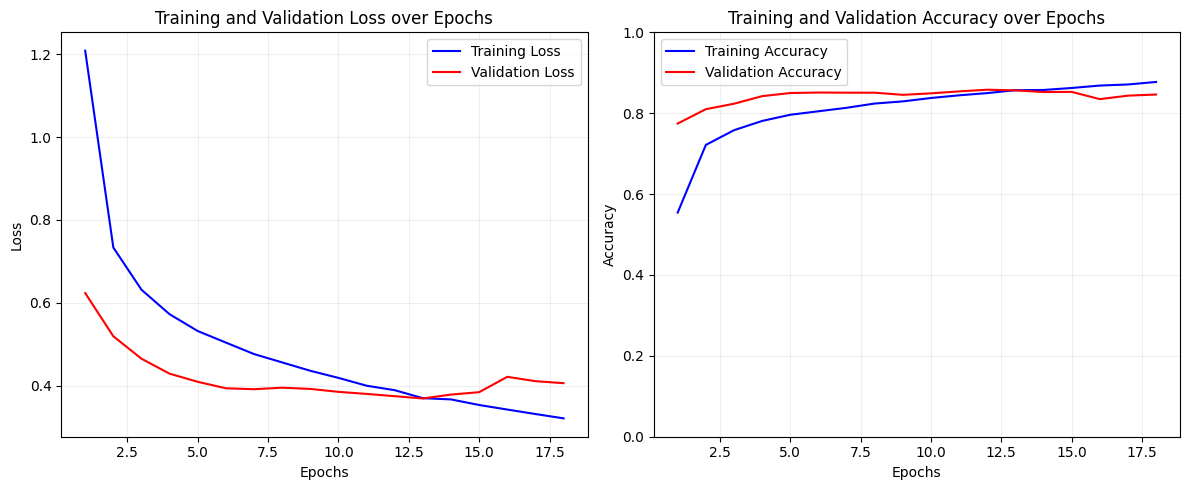

In [45]:
# Visualization
for idx in range(len(dropout_array)):
    dropout_prob = dropout_array[idx]
    plot_loss_acc_curves(train_losses_array_WD[idx], val_losses_array_WD[idx], train_accuracies_array_WD[idx], val_accuracies_array_WD[idx])

#### VII. Batch Norm. + Dropout: 4 Blocks, learning rate: 1e-3, batch_norm: on, dropout_prob: best among 20, 50 and 70% ####

In [47]:
img_size = rows  # square images

dropout_array = [0.2, 0.5, 0.7]
train_losses_array_BN_Drop = []
val_losses_array_BN_Drop = []
train_accuracies_array_BN_Drop = []
val_accuracies_array_BN_Drop = []
test_accuracies_array_BN_Drop = []
test_accuracies_array_BN_Drop = []

for idx in range(len(dropout_array)):
    dropout_prob = dropout_array[idx]
    print(f"\n******************** Training with BatchNorm and Dropout Probability: {dropout_prob*100:.0f}% ********************")
    MyCNN_BN_Drop = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4, batch_norm=True,
                      dropout_prob=dropout_prob) 
    MyCNN_BN_Drop.to(device)

    epochs = 30
    learning_rate = 1e-3
    batch_size = BATCH_SIZE
    criterion = torch.nn.CrossEntropyLoss()

    results_bn_drop = test_config(
        model=MyCNN_BN_Drop,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        criterion=criterion,
        learning_rate=learning_rate,
        epochs=epochs,
        num_of_classes=num_of_classes,
        early_stopping=True,
        patience=5,
        compute_auc=True,
        seed=42,
    )

    train_losses_BN_Drop = results_bn_drop['train_losses']
    val_losses_BN_Drop = results_bn_drop['val_losses']
    train_accuracies_BN_Drop = results_bn_drop['train_accuracies']
    val_accuracies_BN_Drop = results_bn_drop['val_accuracies']
    test_acc_BN_Drop = results_bn_drop['test_acc']
    test_auc_BN_Drop = results_bn_drop['test_auc']
    batch_size = batch_size
    learning_rate = learning_rate

    train_losses_array_BN_Drop.append(train_losses_BN_Drop)
    val_losses_array_BN_Drop.append(val_losses_BN_Drop)
    train_accuracies_array_BN_Drop.append(train_accuracies_BN_Drop)
    val_accuracies_array_BN_Drop.append(val_accuracies_BN_Drop)
    test_accuracies_array_BN_Drop.append(test_acc_BN_Drop)
    test_accuracies_array_BN_Drop.append(test_auc_BN_Drop)


******************** Training with BatchNorm and Dropout Probability: 20% ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.6971, Train Acc: 73.96%
 - Val Loss: 0.3604, Val Acc: 85.56%

Epoch 5
 - Train Loss: 0.1316, Train Acc: 94.36%
 - Val Loss: 0.3440, Val Acc: 88.30%

Early stopping at epoch 9
Best model at epoch 4
==================== Training complete ====================
>>> Test Accuracy: 76.61%
>>> Test AUC: 0.9749

******************** Training with BatchNorm and Dropout Probability: 50% ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.8084, Train Acc: 69.52%
 - Val Loss: 0.4240, Val Acc: 83.16%

Epoch 5
 - Train Loss: 0.1985, Train Acc: 91.65%
 - Val Loss: 0.2728, Val Acc: 89.48%

Early stopping at epoch 8
Best model at epoch 3
==================== Training complete ====================
>>> Test Accuracy: 75.46%
>>> Test AUC:

/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


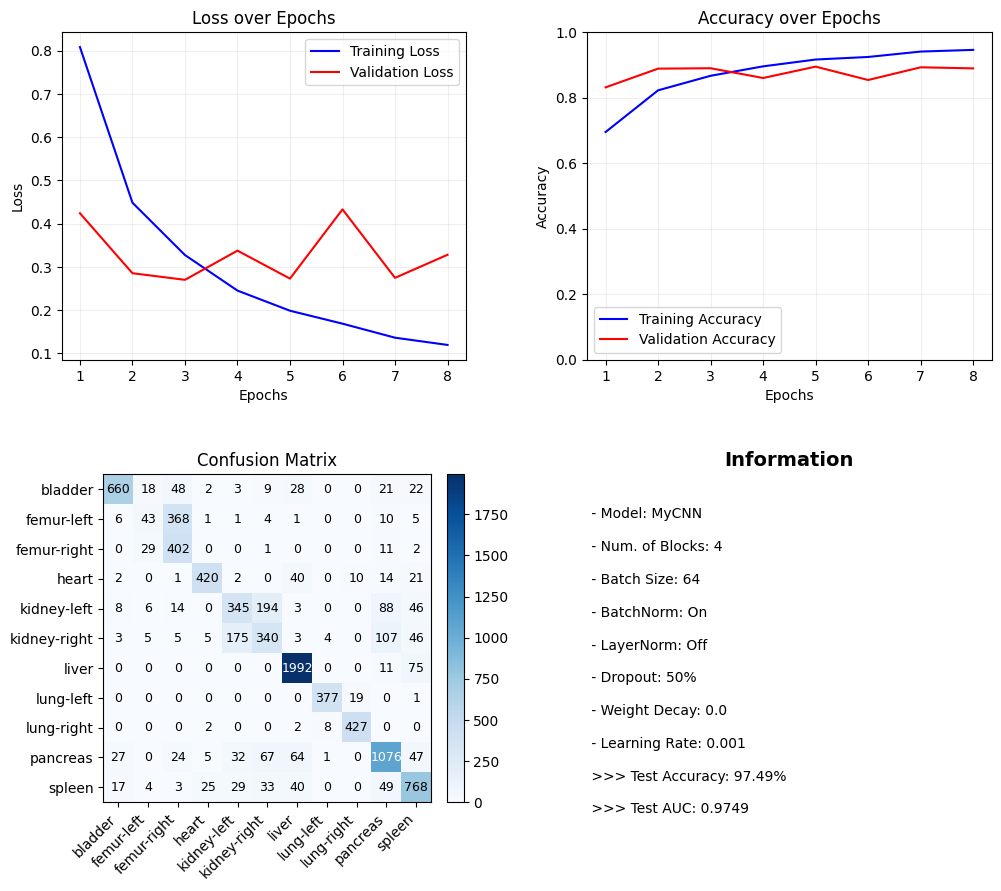

In [48]:
# Visualization for the best dropout probability
best_idx = np.argmax(test_accuracies_array_BN_Drop)
plot_loss_acc_confusion(train_losses_array_BN_Drop[best_idx], val_losses_array_BN_Drop[best_idx], train_accuracies_array_BN_Drop[best_idx], val_accuracies_array_BN_Drop[best_idx], test_accuracies_array_BN_Drop[best_idx],
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=4, batch_norm=True, dropout=dropout_array[best_idx], test_auc=test_accuracies_array_BN_Drop[best_idx])

#### VIII. Batch Norm. + Layer Norm. + Dropout: 4 Blocks, learning rate: 1e-3, batch_norm: on, dropout_prob: best among 20, 50 and 70% ####

In [49]:
img_size = rows  # square images

dropout_array = [0.2, 0.5, 0.7]
train_losses_array_BN_LN_Drop = []
val_losses_array_BN_LN_Drop = []
train_accuracies_array_BN_LN_Drop = []
val_accuracies_array_BN_LN_Drop = []
test_accuracies_array_BN_LN_Drop = []
test_auc_array_BN_LN_Drop = []

for idx in range(len(dropout_array)):
    dropout_prob = dropout_array[idx]
    print(f"\n******************** Training with BatchNorm, LayerNorm and Dropout Probability: {dropout_prob*100:.0f}% ********************")
    MyCNN_BN_LN_Drop = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4, batch_norm=True, 
                             layer_norm=True, dropout_prob=dropout_prob) 
    MyCNN_BN_LN_Drop.to(device)

    epochs = 30
    learning_rate = 1e-3
    batch_size = BATCH_SIZE
    criterion = torch.nn.CrossEntropyLoss()

    results_bn_ln_drop = test_config(
        model=MyCNN_BN_LN_Drop,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        criterion=criterion,
        learning_rate=learning_rate,
        epochs=epochs,
        num_of_classes=num_of_classes,
        early_stopping=True,
        patience=5,
        compute_auc=True,
        seed=42,
    )

    train_losses_BN_LN_Drop = results_bn_ln_drop['train_losses']
    val_losses_BN_LN_Drop = results_bn_ln_drop['val_losses']
    train_accuracies_BN_LN_Drop = results_bn_ln_drop['train_accuracies']
    val_accuracies_BN_LN_Drop = results_bn_ln_drop['val_accuracies']
    test_acc_BN_LN_Drop = results_bn_ln_drop['test_acc']
    test_auc_BN_LN_Drop = results_bn_ln_drop['test_auc']
    batch_size = batch_size
    learning_rate = learning_rate

    train_losses_array_BN_LN_Drop.append(train_losses_BN_LN_Drop)
    val_losses_array_BN_LN_Drop.append(val_losses_BN_LN_Drop)
    train_accuracies_array_BN_LN_Drop.append(train_accuracies_BN_LN_Drop)
    val_accuracies_array_BN_LN_Drop.append(val_accuracies_BN_LN_Drop)
    test_accuracies_array_BN_LN_Drop.append(test_acc_BN_LN_Drop)
    test_auc_array_BN_LN_Drop.append(test_auc_BN_LN_Drop)


******************** Training with BatchNorm, LayerNorm and Dropout Probability: 20% ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.6618, Train Acc: 75.48%
 - Val Loss: 0.3564, Val Acc: 86.26%

Epoch 5
 - Train Loss: 0.0777, Train Acc: 96.86%
 - Val Loss: 0.3085, Val Acc: 89.31%

Early stopping at epoch 8
Best model at epoch 3
==================== Training complete ====================
>>> Test Accuracy: 75.85%
>>> Test AUC: 0.9717

******************** Training with BatchNorm, LayerNorm and Dropout Probability: 50% ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.7592, Train Acc: 72.65%
 - Val Loss: 0.3489, Val Acc: 87.11%

Epoch 5
 - Train Loss: 0.1331, Train Acc: 94.11%
 - Val Loss: 0.3065, Val Acc: 88.74%

Early stopping at epoch 8
Best model at epoch 3
==================== Training complete ====================
>>> Test Accuracy

/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


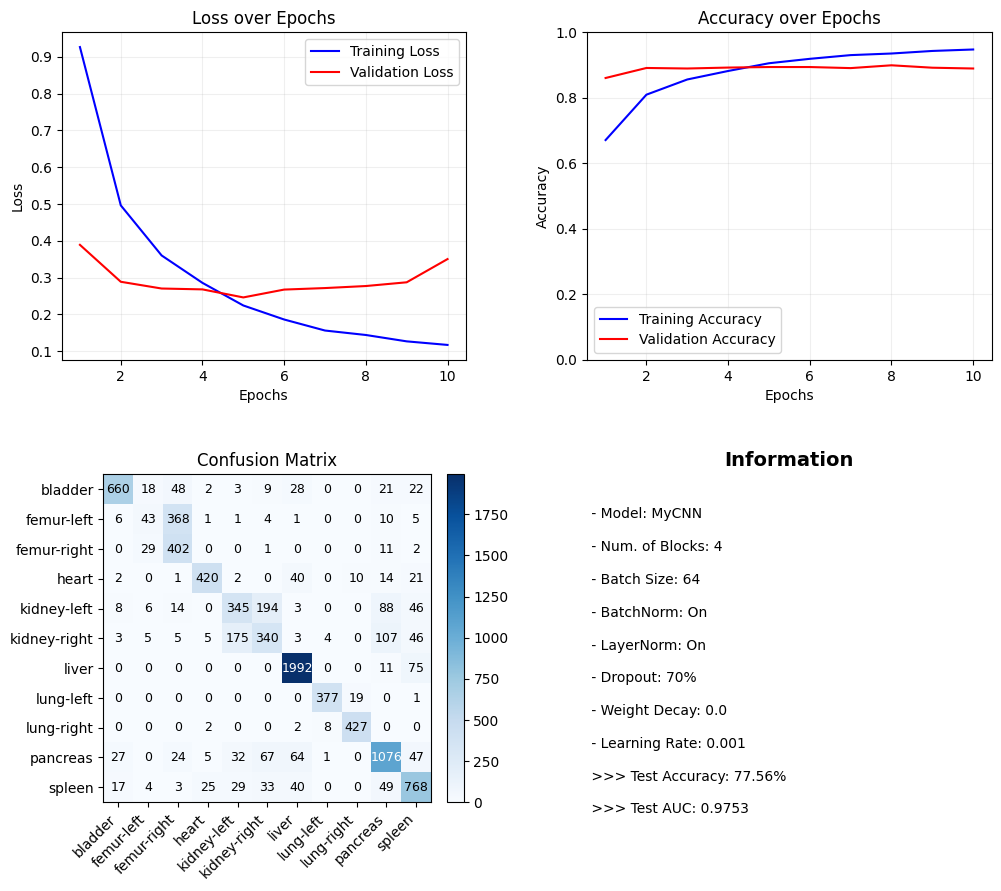

In [50]:
# Visualization for the best dropout probability
best_idx = np.argmax(test_accuracies_array_BN_LN_Drop)
plot_loss_acc_confusion(train_losses_array_BN_LN_Drop[best_idx], val_losses_array_BN_LN_Drop[best_idx], train_accuracies_array_BN_LN_Drop[best_idx], 
                        val_accuracies_array_BN_LN_Drop[best_idx], test_accuracies_array_BN_LN_Drop[best_idx], targets, preds, labels_dict, 
                        model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=4, batch_norm=True, layer_norm=True, 
                        dropout=dropout_array[best_idx], test_auc=test_auc_array_BN_LN_Drop[best_idx])

#### IX. Batch Norm. + Dropout + Weight Decay: 4 Blocks, learning rate: 1e-3, batch_norm: on, dropout_prob: 50%, weight_decay: 1e-3 ####

In [51]:
img_size = rows  # square images

MyCNN_BN_Drop_WD = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4, 
                         batch_norm=True, dropout_prob=0.5)
MyCNN_BN_Drop_WD.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-3
criterion = torch.nn.CrossEntropyLoss()

# create optimizer factory to include weight decay
optimizer_fn = lambda params, lr: torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

results_bn_drop_wd = test_config(
    model=MyCNN_BN_Drop_WD,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    optimizer=optimizer_fn,
    early_stopping=True,
    patience=5,
    compute_auc=True,
    seed=42,
 )

train_losses_BN_Drop_WD = results_bn_drop_wd['train_losses']
val_losses_BN_Drop_WD = results_bn_drop_wd['val_losses']
train_accuracies_BN_Drop_WD = results_bn_drop_wd['train_accuracies']
val_accuracies_BN_Drop_WD = results_bn_drop_wd['val_accuracies']
test_acc_BN_Drop_WD = results_bn_drop_wd['test_acc']
test_auc_BN_Drop_WD = results_bn_drop_wd['test_auc']
targets = results_bn_drop_wd['targets']
preds = results_bn_drop_wd['preds']
batch_size = batch_size
learning_rate = learning_rate

Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.8062, Train Acc: 69.54%
 - Val Loss: 0.3660, Val Acc: 84.79%

Epoch 5
 - Train Loss: 0.2197, Train Acc: 90.67%
 - Val Loss: 0.2852, Val Acc: 88.21%

Epoch 10
 - Train Loss: 0.1247, Train Acc: 94.62%
 - Val Loss: 0.2803, Val Acc: 89.07%

Early stopping at epoch 14
Best model at epoch 9
==================== Training complete ====================
>>> Test Accuracy: 76.78%
>>> Test AUC: 0.9746


/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


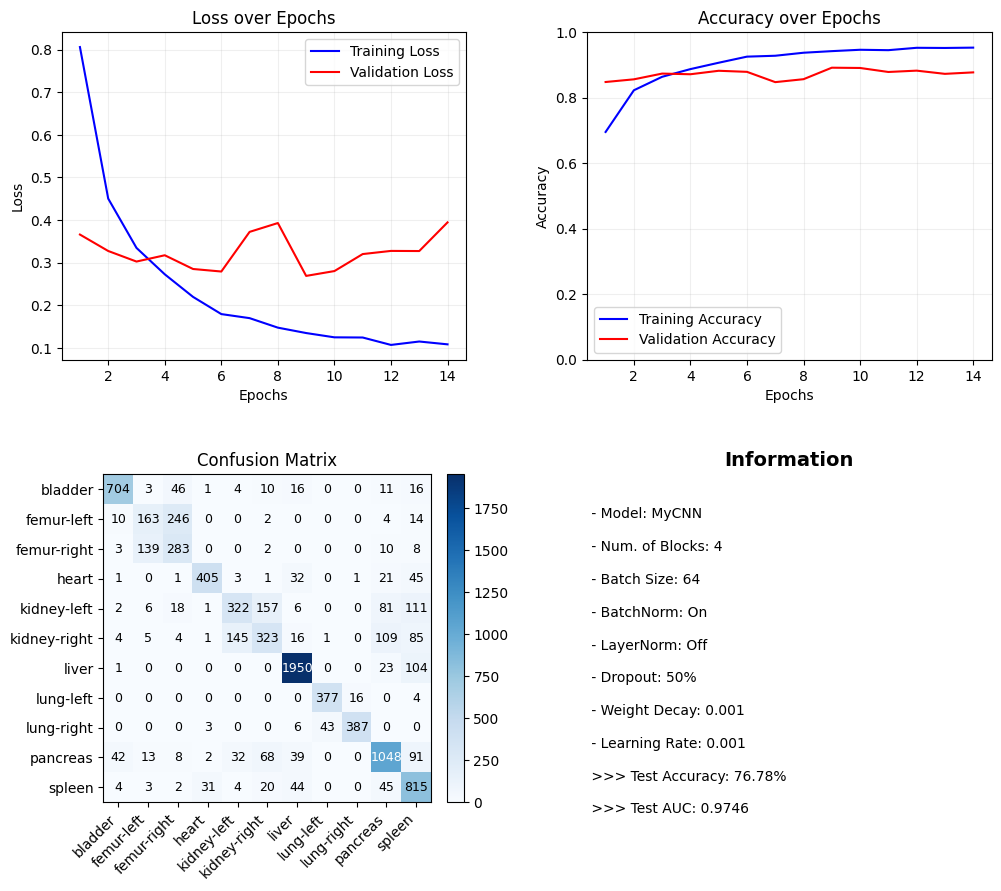

In [52]:
# Visualization
plot_loss_acc_confusion(train_losses_BN_Drop_WD, val_losses_BN_Drop_WD, train_accuracies_BN_Drop_WD, val_accuracies_BN_Drop_WD, test_acc_BN_Drop_WD,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=4, batch_norm=True, 
                          dropout=0.5, weight_decay=weight_decay, test_auc=test_auc_BN_Drop_WD)

#### X. Batch Norm. + Layer Norm. + Dropout + Weight Decay: dropout_prob: 50%, weight_decay: 1e-4 ####

In [53]:
img_size = rows  # square images

MyCNN_BN_LN_Drop_WD = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4, 
                            batch_norm=True, layer_norm=True, dropout_prob=0.5)
MyCNN_BN_LN_Drop_WD.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-4
criterion = torch.nn.CrossEntropyLoss()

# optimizer factory including weight decay
optimizer_fn = lambda params, lr: torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

results_bn_ln_drop_wd = test_config(
    model=MyCNN_BN_LN_Drop_WD,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    optimizer=optimizer_fn,
    early_stopping=True,
    patience=5,
    compute_auc=True,
    seed=42,
 )

train_losses_BN_LN_Drop_WD = results_bn_ln_drop_wd['train_losses']
val_losses_BN_LN_Drop_WD = results_bn_ln_drop_wd['val_losses']
train_accuracies_BN_LN_Drop_WD = results_bn_ln_drop_wd['train_accuracies']
val_accuracies_BN_LN_Drop_WD = results_bn_ln_drop_wd['val_accuracies']
test_acc_BN_LN_Drop_WD = results_bn_ln_drop_wd['test_acc']
test_auc_BN_LN_Drop_WD = results_bn_ln_drop_wd['test_auc']
targets = results_bn_ln_drop_wd['targets']
preds = results_bn_ln_drop_wd['preds']
batch_size = batch_size
learning_rate = learning_rate

Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.7835, Train Acc: 71.60%
 - Val Loss: 0.4005, Val Acc: 83.56%

Epoch 5
 - Train Loss: 0.1380, Train Acc: 94.01%
 - Val Loss: 0.2967, Val Acc: 88.91%

Early stopping at epoch 8
Best model at epoch 3
==================== Training complete ====================
>>> Test Accuracy: 75.85%
>>> Test AUC: 0.9730


/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


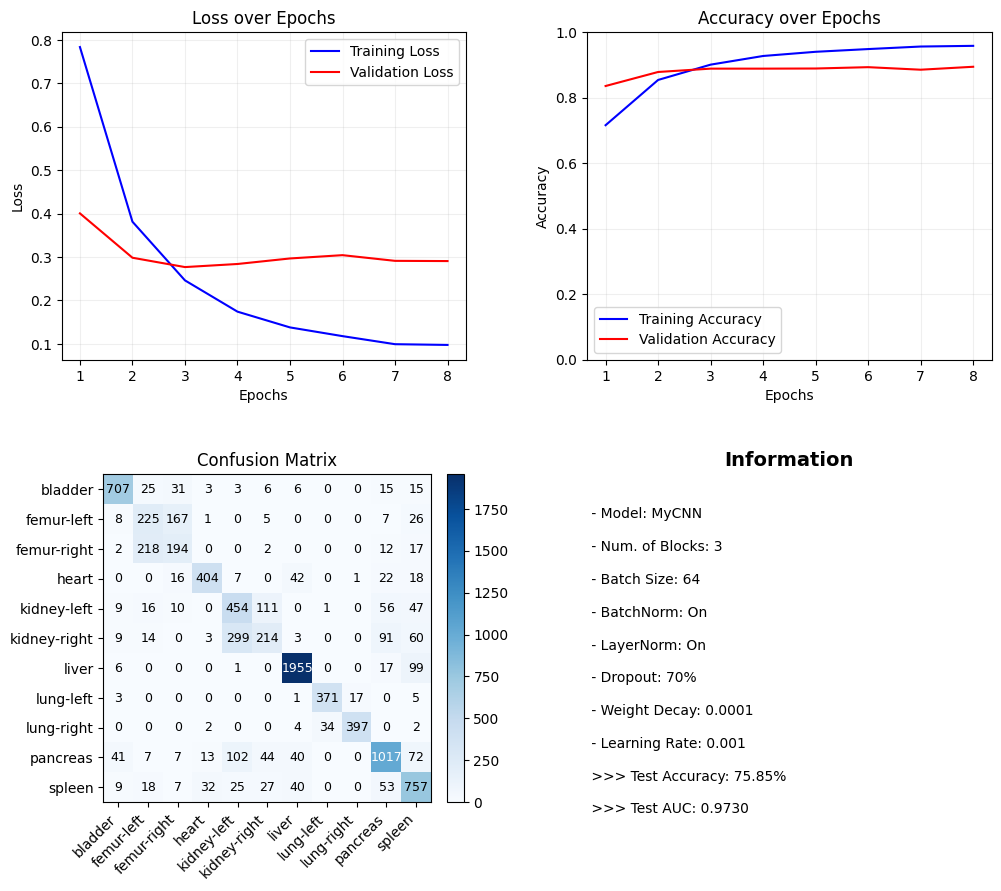

In [54]:
# Visualization
plot_loss_acc_confusion(train_losses_BN_LN_Drop_WD, val_losses_BN_LN_Drop_WD, train_accuracies_BN_LN_Drop_WD, val_accuracies_BN_LN_Drop_WD, test_acc_BN_LN_Drop_WD,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, batch_norm=True, 
                          layer_norm=True, dropout=0.7, weight_decay=weight_decay, test_auc=test_auc_BN_LN_Drop_WD)

#### XI. Layer Norm. + Dropout: dropout_prob: best among 20, 50, 70% ####

In [55]:
img_size = rows  # square images

dropout_array = [0.2, 0.5, 0.7]
train_losses_array_LN_Drop = []
val_losses_array_LN_Drop = []
train_accuracies_array_LN_Drop = []
val_accuracies_array_LN_Drop = []
test_accuracies_array_LN_Drop = []
test_auc_array_LN_Drop = []

for idx in range(len(dropout_array)):
    dropout_prob = dropout_array[idx]
    print(f"\n******************** Training with LayerNorm and Dropout Probability: {dropout_prob*100:.0f}% ********************")
    MyCNN_LN_Drop = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4, layer_norm=True, 
                          dropout_prob=dropout_prob)
    MyCNN_LN_Drop.to(device)

    epochs = 30
    learning_rate = 1e-3
    batch_size = BATCH_SIZE
    criterion = torch.nn.CrossEntropyLoss()

    results_ln_drop = test_config(
        model=MyCNN_LN_Drop,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        criterion=criterion,
        learning_rate=learning_rate,
        epochs=epochs,
        num_of_classes=num_of_classes,
        early_stopping=True,
        patience=5,
        compute_auc=True,
        seed=42,
    )

    train_losses_LN_Drop = results_ln_drop['train_losses']
    val_losses_LN_Drop = results_ln_drop['val_losses']
    train_accuracies_LN_Drop = results_ln_drop['train_accuracies']
    val_accuracies_LN_Drop = results_ln_drop['val_accuracies']
    test_acc_LN_Drop = results_ln_drop['test_acc']
    test_auc_LN_Drop = results_ln_drop['test_auc']
    batch_size = batch_size
    learning_rate = learning_rate

    train_losses_array_LN_Drop.append(train_losses_LN_Drop)
    val_losses_array_LN_Drop.append(val_losses_LN_Drop)
    train_accuracies_array_LN_Drop.append(train_accuracies_LN_Drop)
    val_accuracies_array_LN_Drop.append(val_accuracies_LN_Drop)
    test_accuracies_array_LN_Drop.append(test_acc_LN_Drop)
    test_auc_array_LN_Drop.append(test_auc_LN_Drop)


******************** Training with LayerNorm and Dropout Probability: 20% ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.7459, Train Acc: 72.81%
 - Val Loss: 0.3430, Val Acc: 86.79%

Epoch 5
 - Train Loss: 0.1012, Train Acc: 95.54%
 - Val Loss: 0.3472, Val Acc: 88.21%

Early stopping at epoch 7
Best model at epoch 2
==================== Training complete ====================
>>> Test Accuracy: 75.87%
>>> Test AUC: 0.9723

******************** Training with LayerNorm and Dropout Probability: 50% ********************
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.8063, Train Acc: 70.43%
 - Val Loss: 0.3824, Val Acc: 84.26%

Epoch 5
 - Train Loss: 0.1333, Train Acc: 94.09%
 - Val Loss: 0.3152, Val Acc: 88.83%

Early stopping at epoch 8
Best model at epoch 3
==================== Training complete ====================
>>> Test Accuracy: 76.57%
>>> Test AUC:

/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


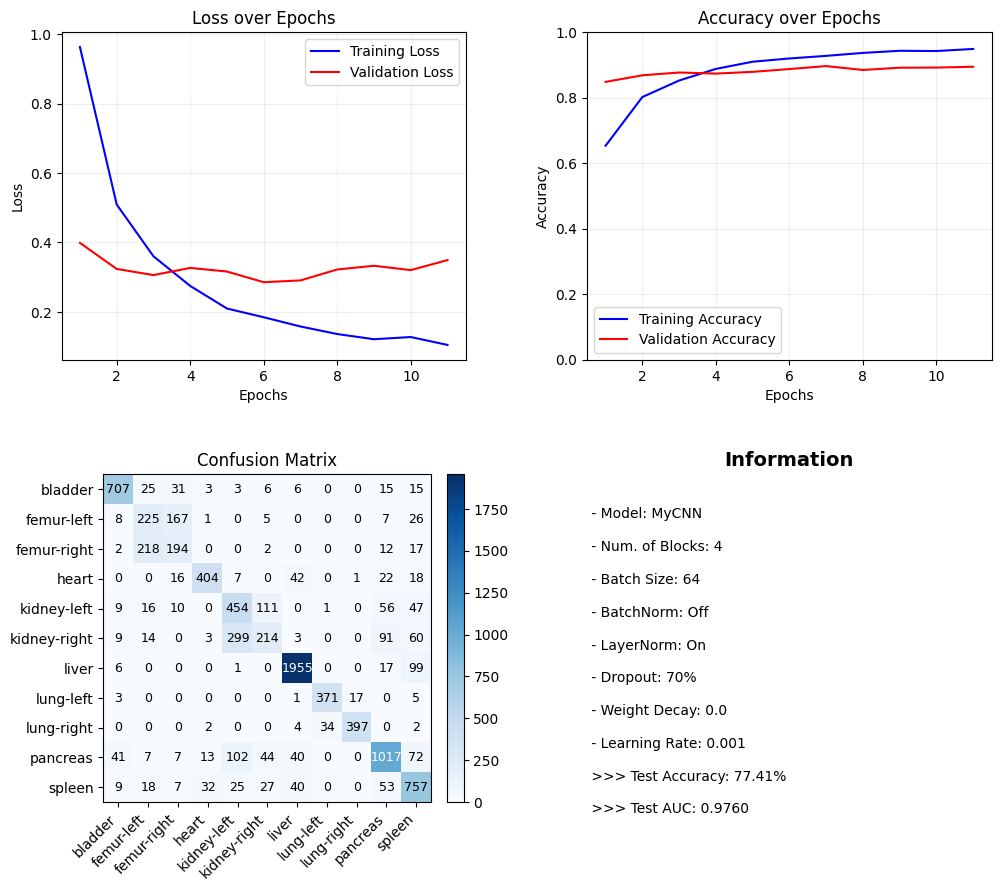

In [56]:
# Visualization for the best dropout probability
best_idx = np.argmax(test_accuracies_array_LN_Drop)
plot_loss_acc_confusion(train_losses_array_LN_Drop[best_idx], val_losses_array_LN_Drop[best_idx], train_accuracies_array_LN_Drop[best_idx], 
                        val_accuracies_array_LN_Drop[best_idx], test_accuracies_array_LN_Drop[best_idx], targets, preds, labels_dict, model_name="MyCNN", 
                        batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=4, layer_norm=True, dropout=dropout_array[best_idx], 
                        test_auc=test_auc_array_LN_Drop[best_idx])

#### XII. Layer Norm. + Dropout + Weight Decay: dropout_prob: 70%, weight_decay: 1e-4 ####

In [57]:
img_size = rows  # square images

MyCNN_LN_Drop_WD = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4, layer_norm=True, 
                         dropout_prob=0.5)
MyCNN_LN_Drop_WD.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-4
criterion = torch.nn.CrossEntropyLoss()

# optimizer factory including weight decay
optimizer_fn = lambda params, lr: torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

results_ln_drop_wd = test_config(
    model=MyCNN_LN_Drop_WD,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    optimizer=optimizer_fn,
    early_stopping=True,
    patience=5,
    compute_auc=True,
    seed=42,
 )

train_losses_LN_Drop_WD = results_ln_drop_wd['train_losses']
val_losses_LN_Drop_WD = results_ln_drop_wd['val_losses']
train_accuracies_LN_Drop_WD = results_ln_drop_wd['train_accuracies']
val_accuracies_LN_Drop_WD = results_ln_drop_wd['val_accuracies']
test_acc_LN_Drop_WD = results_ln_drop_wd['test_acc']
test_auc_LN_Drop_WD = results_ln_drop_wd['test_auc']
targets = results_ln_drop_wd['targets']
preds = results_ln_drop_wd['preds']
batch_size = batch_size
learning_rate = learning_rate

Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.8414, Train Acc: 68.99%
 - Val Loss: 0.3668, Val Acc: 84.83%

Epoch 5
 - Train Loss: 0.1415, Train Acc: 93.75%
 - Val Loss: 0.3003, Val Acc: 89.15%

Early stopping at epoch 10
Best model at epoch 5
==================== Training complete ====================
>>> Test Accuracy: 76.40%
>>> Test AUC: 0.9730


/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


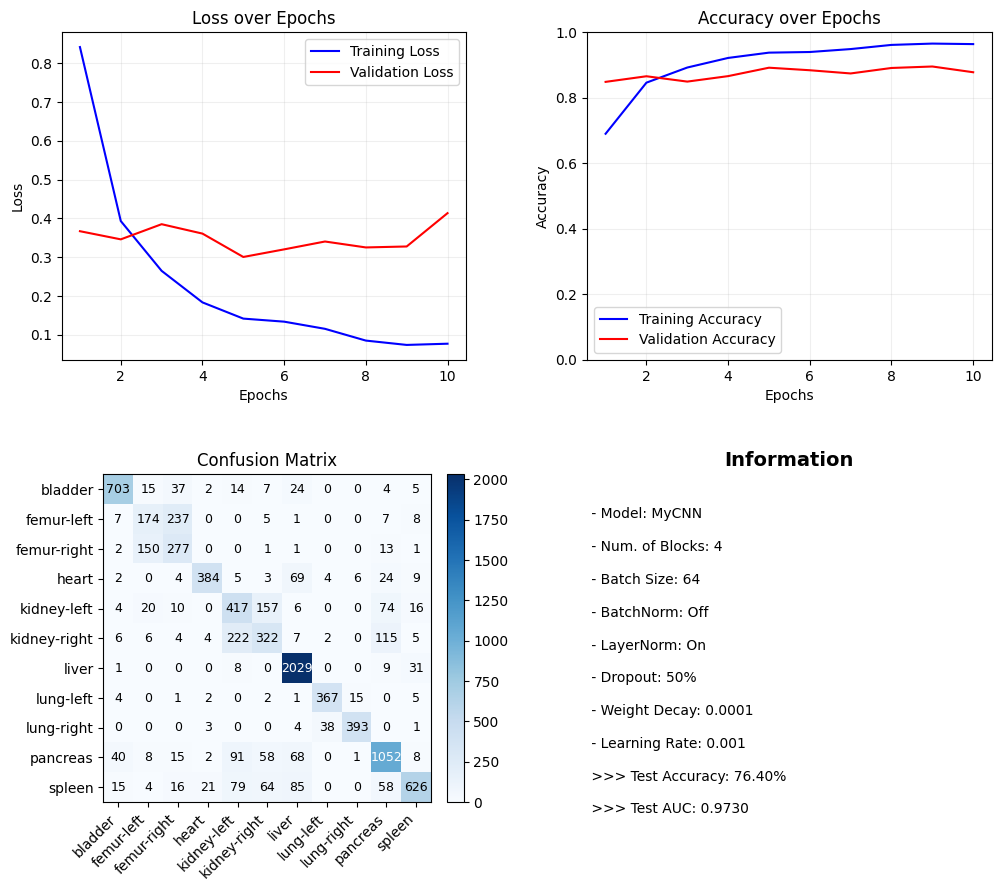

In [58]:
# Visualization
plot_loss_acc_confusion(train_losses_LN_Drop_WD, val_losses_LN_Drop_WD, train_accuracies_LN_Drop_WD, val_accuracies_LN_Drop_WD, test_acc_LN_Drop_WD,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, 
                          num_of_blocks=4, layer_norm=True, dropout=0.5, weight_decay=weight_decay, test_auc=test_auc_LN_Drop_WD)

### 2.3 Additional Training Techniques ###

#### Data Augmentation  ####

In [59]:
from torchvision import transforms

# Define image to tensor transform + data augmentation
data_transform_aug = transforms.Compose([
    # augmetation
    # transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=None),

    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) 
])

# Setup training, validation, and test datasets
train_dataset_aug = OrganSMNIST(split="train", download=True, transform=data_transform_aug)
val_dataset_aug = OrganSMNIST(split="val", download=True, transform=data_transform_aug)
test_dataset_aug = OrganSMNIST(split="test", download=True, transform=data_transform_aug)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 64
torch.manual_seed(42) 
train_data_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
val_data_aug = DataLoader(val_dataset_aug, batch_size=BATCH_SIZE, shuffle=False)
test_data_aug = DataLoader(test_dataset_aug, batch_size=BATCH_SIZE, shuffle=False)

#### Data Aug. + LR Scheduling: 4 Blocks, 64 filters, batch_norm: on, layer_norm: on, dropout_prob: 50%, weight_decay: 1e-4 ####

In [68]:
img_size = rows  # square images

MyCNN_LN_Drop = MyCNN(img_size=img_size, num_of_channels=channels, num_of_filters=64, num_of_classes=num_of_classes, num_of_blocks=4, 
                     batch_norm=True, layer_norm=True, dropout_prob=0.5)
MyCNN_LN_Drop.to(device)

epochs = 40
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-4
criterion = torch.nn.CrossEntropyLoss()
# optimizer factory including weight decay
optimizer_fn = lambda params, lr: torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

scheduler_factor = 0.1
scheduler_patience = 3

early_stopping = True
patience = 5

results_aug = test_config(
    model=MyCNN_LN_Drop,
    train_data=train_data_aug,
    val_data=val_data_aug,
    test_data=test_data_aug,
    criterion=criterion,
    learning_rate=learning_rate,
    scheduler_factor=scheduler_factor,
    scheduler_patience=scheduler_patience,
    epochs=epochs,
    num_of_classes=num_of_classes,
    optimizer=optimizer_fn,
    early_stopping=early_stopping,
    patience=patience,
    compute_auc=True, 
    seed=42,
    )

train_losses_aug = results_aug['train_losses']
val_losses_aug = results_aug['val_losses']
train_accuracies_aug = results_aug['train_accuracies']
val_accuracies_aug = results_aug['val_accuracies']
test_acc_aug = results_aug['test_acc']
test_auc_aug = results_aug['test_auc']
targets = results_aug['targets']
preds = results_aug['preds']

Using device: cuda
Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.9049, Train Acc: 66.82%
 - Val Loss: 0.4324, Val Acc: 83.24%

Epoch 5
 - Train Loss: 0.3587, Train Acc: 84.91%
 - Val Loss: 0.3034, Val Acc: 88.09%

Epoch 10
 - Train Loss: 0.1861, Train Acc: 92.13%
 - Val Loss: 0.2564, Val Acc: 90.25%

Epoch 15
 - Train Loss: 0.1473, Train Acc: 93.72%
 - Val Loss: 0.2460, Val Acc: 89.52%

Early stopping at epoch 18
Best model at epoch 13
==================== Training complete ====================
>>> Test Accuracy: 78.58%
>>> Test AUC: 0.9771


/tmp/ipykernel_7626/2733902910.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


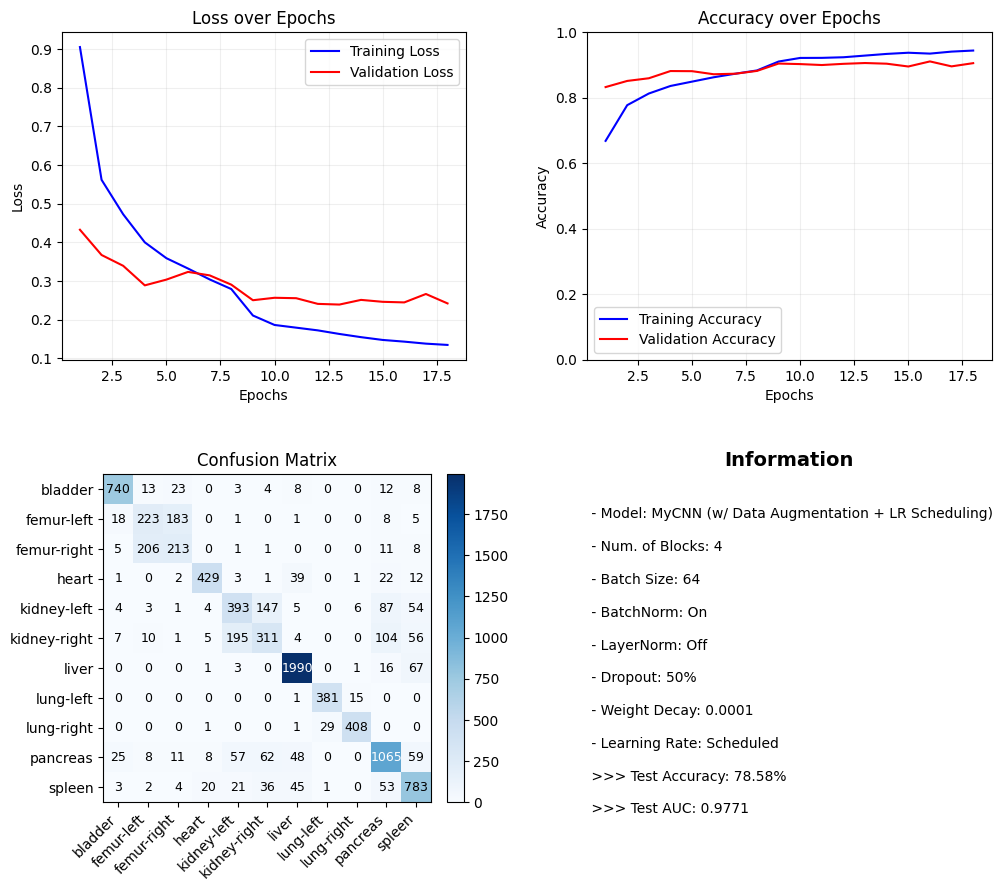

In [70]:
# Visualization
plot_loss_acc_confusion(train_losses_aug, val_losses_aug, train_accuracies_aug, val_accuracies_aug, test_acc_aug,
                          targets, preds, labels_dict, model_name="MyCNN (w/ Data Augmentation + LR Scheduling)", batch_size=batch_size, learning_rate="Scheduled", 
                          num_of_blocks=4, batch_norm=True, dropout=0.5, weight_decay=weight_decay, test_auc=test_auc_aug)

## **3.** CNN utilizing Transfer Learning ##

### 3.1 Feature Extraction ###

In [10]:
import torch
import torch.nn as nn
from torchvision import models

# Setup ResNet18 for feature extraction
resNet18_FE = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in resNet18_FE.parameters():
    param.requires_grad = False

# Get output features and add fully connected layer
num_features = resNet18_FE.fc.in_features
resNet18_FE.fc = nn.Linear(num_features, num_of_classes)

# Unfreeze the fully connected layer
for param in resNet18_FE.fc.parameters():
    param.requires_grad = True

resNet18_FE = resNet18_FE.to(device)

#### Classifier head training: Adam Optimizer, learning rate: 1e-3, Batch size: 64 ####

In [11]:
# Define image to tensor transform 
data_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet18 expects 224x224 input
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_224 = OrganSMNIST(split="train", download=True, transform=data_transform_224)
val_dataset_224 = OrganSMNIST(split="val", download=True, transform=data_transform_224)
test_dataset_224 = OrganSMNIST(split="test", download=True, transform=data_transform_224)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 64
torch.manual_seed(42) 
train_data_224 = DataLoader(train_dataset_224, batch_size=BATCH_SIZE, shuffle=True)
val_data_224 = DataLoader(val_dataset_224, batch_size=BATCH_SIZE, shuffle=False)
test_data_224 = DataLoader(test_dataset_224, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
epochs = 25
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()

# Initialize results via test_config
results_resNet18_FE = test_config(
    model=resNet18_FE,
    train_data=train_data_224,
    val_data=val_data_224,
    test_data=test_data_224,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    optimizer=torch.optim.Adam,
    early_stopping=True,
    patience=5,
    compute_auc=True,
    seed=42,
 )

train_losses_resNet18_FE = results_resNet18_FE['train_losses']
val_losses_resNet18_FE = results_resNet18_FE['val_losses']
train_accuracies_resNet18_FE = results_resNet18_FE['train_accuracies']
val_accuracies_resNet18_FE = results_resNet18_FE['val_accuracies']
test_acc_resNet18_FE = results_resNet18_FE['test_acc']
test_auc_resNet18_FE = results_resNet18_FE['test_auc']
targets = results_resNet18_FE['targets']
preds = results_resNet18_FE['preds']

Using device: cpu
==================== Starting Training ====================
Epoch 1
 - Train Loss: 1.2953, Train Acc: 55.85%
 - Val Loss: 0.7674, Val Acc: 74.23%

Epoch 5
 - Train Loss: 0.6930, Train Acc: 74.66%
 - Val Loss: 0.5216, Val Acc: 80.55%



In [9]:
# Visualization
plot_loss_acc_confusion(train_losses_resNet18_FE, val_losses_resNet18_FE, train_accuracies_resNet18_FE, val_accuracies_resNet18_FE, test_acc_resNet18_FE,
                          targets, preds, labels_dict,"resNet18, Feature extraction", batch_size, learning_rate, test_auc=test_auc_resNet18_FE)

NameError: name 'train_losses_resNet18_FE' is not defined

### 3.2 Fine-Tuning ###

In [8]:
import torch
import torch.nn as nn
from torchvision import models

# Setup ResNet18 for fine-tuning
resNet18_FT = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#print(resNet18_FT)

# Freeze all layers
for param in resNet18_FT.parameters():
    param.requires_grad = False

# Get output features and add fully connected layer
num_features = resNet18_FT.fc.in_features
resNet18_FT.fc = nn.Linear(num_features, num_of_classes)

# Unfreeze the fully connected layer
for param in resNet18_FT.fc.parameters():
    param.requires_grad = True

# Unfreeze last two blocks
for param in resNet18_FT.layer4.parameters(): # last 2 blocks: BasicBlock0 and BasicBlock1 in layer4
    param.requires_grad = True    

resNet18_FT = resNet18_FT.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s] 


#### Classifier head and last 2 blocks training: Adam Optimizer, learning rate: 1e-4, Batch size: 32 ####

In [77]:
# Define image to tensor transform 
data_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet18 expects 224x224 input
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_224 = OrganSMNIST(split="train", download=True, transform=data_transform_224)
val_dataset_224 = OrganSMNIST(split="val", download=True, transform=data_transform_224)
test_dataset_224 = OrganSMNIST(split="test", download=True, transform=data_transform_224)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 32
torch.manual_seed(42) 
train_data_224 = DataLoader(train_dataset_224, batch_size=BATCH_SIZE, shuffle=True)
val_data_224 = DataLoader(val_dataset_224, batch_size=BATCH_SIZE, shuffle=False)
test_data_224 = DataLoader(test_dataset_224, batch_size=BATCH_SIZE, shuffle=False)

In [78]:
epochs = 15
learning_rate = 1e-4
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()

# Initialize results via test_config
results_resNet18_FT = test_config(
    model=resNet18_FT,
    train_data=train_data_224,
    val_data=val_data_224,
    test_data=test_data_224,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    optimizer=torch.optim.Adam,
    early_stopping=True,
    patience=5,
    compute_auc=True,
    seed=42,
 )

train_losses_resNet18_FT = results_resNet18_FT['train_losses']
val_losses_resNet18_FT = results_resNet18_FT['val_losses']
train_accuracies_resNet18_FT = results_resNet18_FT['train_accuracies']
val_accuracies_resNet18_FT = results_resNet18_FT['val_accuracies']
test_acc_resNet18_FT = results_resNet18_FT['test_acc']
test_auc_resNet18_FT = results_resNet18_FT['test_auc']
targets = results_resNet18_FT['targets']
preds = results_resNet18_FT['preds']

Using device: cuda
==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.5584, Train Acc: 79.83%
 - Val Loss: 0.2588, Val Acc: 89.23%

Epoch 5
 - Train Loss: 0.0262, Train Acc: 99.30%
 - Val Loss: 0.2414, Val Acc: 91.80%

Early stopping at epoch 9
Best model at epoch 4
==================== Training complete ====================
>>> Test Accuracy: 79.35%
>>> Test AUC: 0.9765


/tmp/ipython-input-2488120122.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


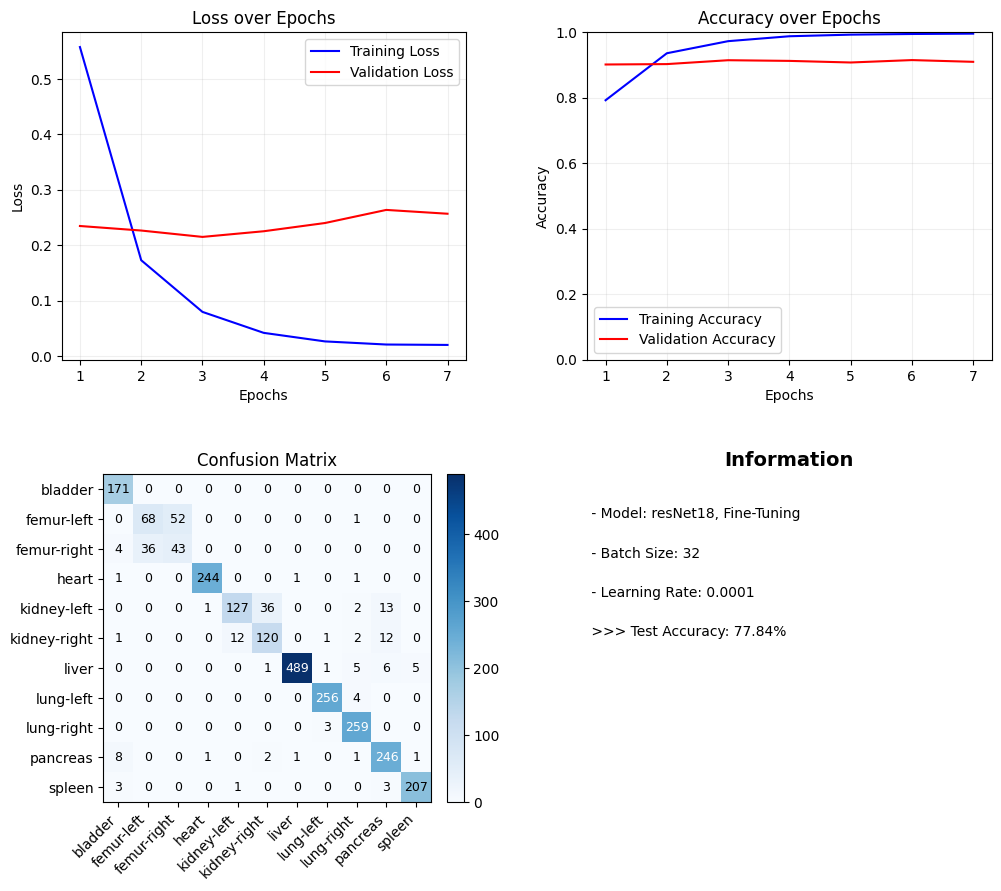

In [ ]:
# Visualization
plot_loss_acc_confusion(train_losses_resNet18_FT, val_losses_resNet18_FT, train_accuracies_resNet18_FT, val_accuracies_resNet18_FT, test_acc_resNet18_FT,
                          targets, preds, labels_dict,"resNet18, Fine-Tuning", batch_size, learning_rate, test_auc=test_auc_resNet18_FT)

## **4.** Small Vision Transformer (DeiT) ##

### 4.1 Feature Extraction ###

In [127]:
import timm

# Set up DeiT-Tiny
DeiT = timm.create_model(
    "deit_tiny_patch16_224",
    pretrained=True,
    num_classes=num_of_classes
).to(device)

# Freeze all layers
for param in DeiT.parameters():
    param.requires_grad = False

# Unfreeze the classifier head
for param in DeiT.head.parameters():
    param.requires_grad = True

DeiT = DeiT.to(device)

#### Classifier head training: Adam optimizer, learning rate: 1e-3. Batch size: 32 #### 

In [128]:
# Define image to tensor transform 
data_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),  # DeiT expects 224x224 input
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_224 = OrganSMNIST(split="train", download=True, transform=data_transform_224)
val_dataset_224 = OrganSMNIST(split="val", download=True, transform=data_transform_224)
test_dataset_224 = OrganSMNIST(split="test", download=True, transform=data_transform_224)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 32
torch.manual_seed(42) 
train_data_224 = DataLoader(train_dataset_224, batch_size=BATCH_SIZE, shuffle=True)
val_data_224 = DataLoader(val_dataset_224, batch_size=BATCH_SIZE, shuffle=False)
test_data_224 = DataLoader(test_dataset_224, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
epochs = 15
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()

early_stopping = True
patience = 5

results_DeiT_FE = test_config(
    model=DeiT,
    train_data=train_data_224,
    val_data=val_data_224,
    test_data=test_data_224,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    early_stopping=early_stopping,
    patience=patience,
    compute_auc=True,
    seed=42,
    )

train_losses_DeiT_FE = results_DeiT_FE['train_losses']
val_losses_DeiT_FE = results_DeiT_FE['val_losses']
train_accuracies_DeiT_FE = results_DeiT_FE['train_accuracies']
val_accuracies_DeiT_FE = results_DeiT_FE['val_accuracies']
test_acc_DeiT_FE = results_DeiT_FE['test_acc']
test_auc_DeiT_FE = results_DeiT_FE['test_auc']
targets = results_DeiT_FE['targets']
preds = results_DeiT_FE['preds'] 

==================== Starting Training ====================
Epoch 1
 - Train Loss: 1.1228, Train Acc: 61.81%
 - Val Loss: 0.6889, Val Acc: 75.94%

Epoch 5
 - Train Loss: 0.6216, Train Acc: 77.00%
 - Val Loss: 0.4987, Val Acc: 81.69%

Epoch 10
 - Train Loss: 0.5581, Train Acc: 78.85%
 - Val Loss: 0.4762, Val Acc: 81.61%

Early stopping at epoch 11
Best model at epoch 8
==================== Training complete ====================
>>> Test Accuracy: 70.28%


/tmp/ipython-input-2488120122.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


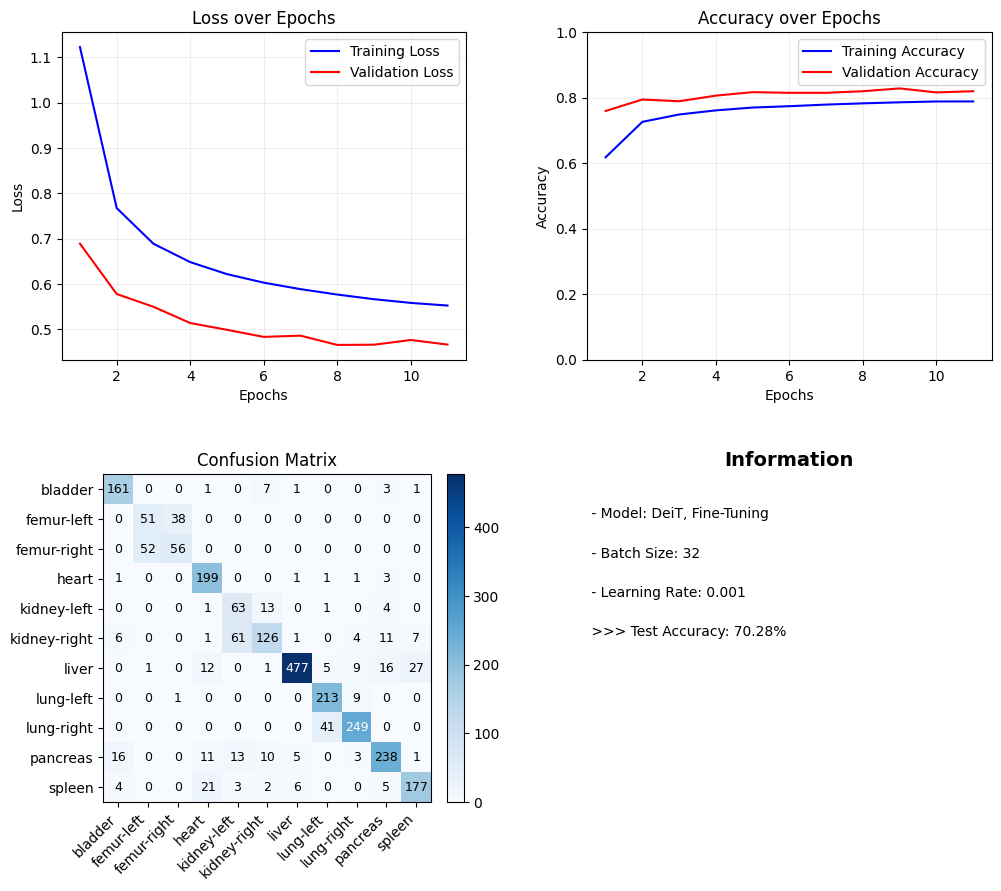

In [130]:
# Visualization
plot_loss_acc_confusion(train_losses_Deit_FE, val_losses_Deit_FE, train_accuracies_Deit_FE, val_accuracies_Deit_FE, test_acc_Deit_FE,
                          targets, preds, labels_dict,"DeiT, Fine-Tuning", batch_size, learning_rate)

### 4.2 Fine-Tuning ###

In [131]:
import timm

# Set up DeiT-Tiny for fine-tuning
DeiT_FT = timm.create_model(
    "deit_tiny_patch16_224",
    pretrained=True,
    num_classes=num_of_classes
).to(device)

# Freeze all layers 
for param in DeiT_FT.parameters():
    param.requires_grad = False

# Unfreeze the classifier head
for param in DeiT_FT.head.parameters():
    param.requires_grad = True

# Unfreeze last transformer block
for param in DeiT_FT.blocks[-1].parameters(): 
    param.requires_grad = True

DeiT_FT = DeiT_FT.to(device)

#### Classifier head and last transformer block training: Adam optimizer, learning rate: 1e-4. Batch size: 16 #### 

In [132]:
# Define image to tensor transform 
data_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),  # DeiT expects 224x224 input
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_224 = OrganSMNIST(split="train", download=True, transform=data_transform_224)
val_dataset_224 = OrganSMNIST(split="val", download=True, transform=data_transform_224)
test_dataset_224 = OrganSMNIST(split="test", download=True, transform=data_transform_224)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 16
torch.manual_seed(42) 
train_data_224 = DataLoader(train_dataset_224, batch_size=BATCH_SIZE, shuffle=True)
val_data_224 = DataLoader(val_dataset_224, batch_size=BATCH_SIZE, shuffle=False)
test_data_224 = DataLoader(test_dataset_224, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
epochs = 10
learning_rate = 1e-4
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()

early_stopping = True
patience = 10

results_DeiT_FT = test_config(
    model=DeiT_FT,
    train_data=train_data_224,
    val_data=val_data_224,
    test_data=test_data_224,
    criterion=criterion,
    learning_rate=learning_rate,
    epochs=epochs,
    num_of_classes=num_of_classes,
    early_stopping=early_stopping,
    patience=patience,
    compute_auc=True,
    seed=42,
    )

train_losses_DeiT_FT = results_DeiT_FT['train_losses']
val_losses_DeiT_FT = results_DeiT_FT['val_losses']
train_accuracies_DeiT_FT = results_DeiT_FT['train_accuracies']
val_accuracies_DeiT_FT = results_DeiT_FT['val_accuracies']
test_acc_DeiT_FT = results_DeiT_FT['test_acc']
test_auc_DeiT_FT = results_DeiT_FT['test_auc']
targets = results_DeiT_FT['targets']
preds = results_DeiT_FT['preds']

==================== Starting Training ====================
Epoch 1
 - Train Loss: 0.9556, Train Acc: 65.25%
 - Val Loss: 0.5240, Val Acc: 80.46%

Epoch 5
 - Train Loss: 0.2324, Train Acc: 90.56%
 - Val Loss: 0.3950, Val Acc: 85.07%

Epoch 10
 - Train Loss: 0.0625, Train Acc: 97.39%
 - Val Loss: 0.5662, Val Acc: 83.65%

==================== Training complete ====================
>>> Test Accuracy: 73.42%


/tmp/ipython-input-2488120122.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


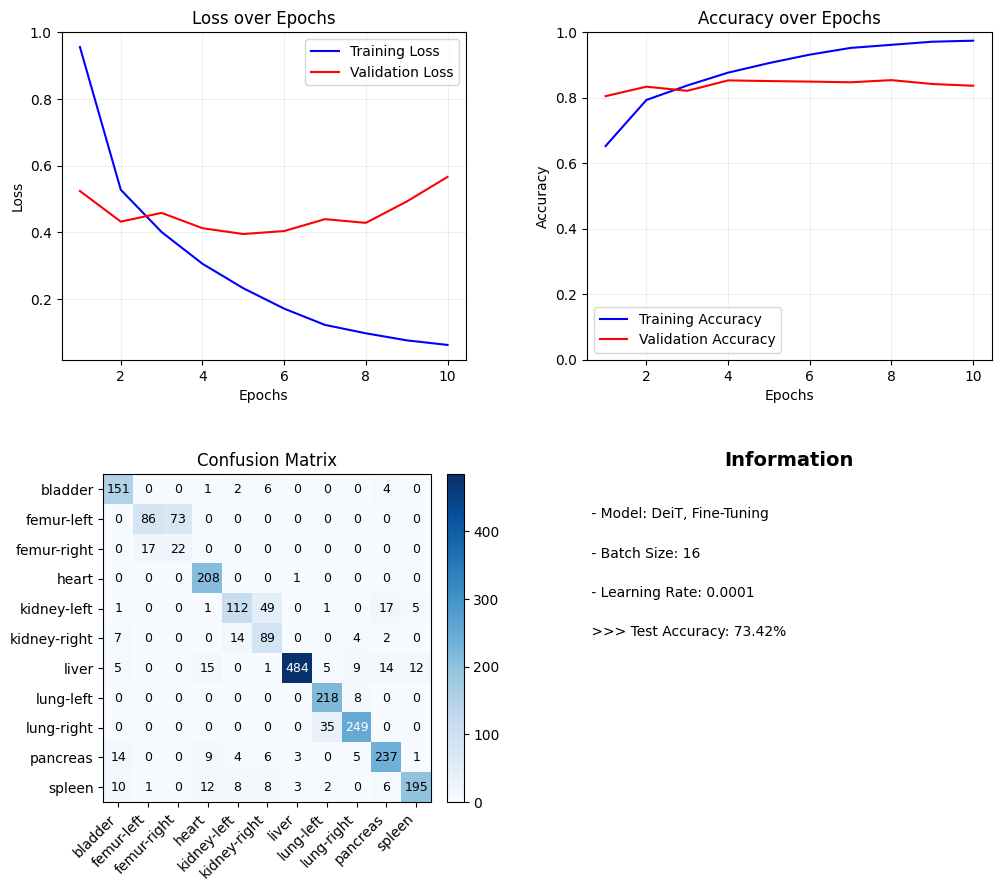

In [134]:
# Visualization
plot_loss_acc_confusion(train_losses_Deit_FT, val_losses_Deit_FT, train_accuracies_Deit_FT, val_accuracies_Deit_FT, test_acc_Deit_FT,
                          targets, preds, labels_dict,"DeiT, Fine-Tuning", batch_size, learning_rate)